# DORAnet → enzyme hypotheses → DNA design (one example compound)

This notebook converts DORAnet-generated reaction networks into concise downstream design tables: parsed reactions, enzyme hypotheses, enzyme-candidate templates, and non-operational DNA design plans for expert review.

In [10]:
from pathlib import Path
import glob
import json
import os
import re
import textwrap
import numpy as np
import pandas as pd
import pubchempy as pcp
from tqdm.auto import tqdm
from rdkit import Chem, rdBase
from rdkit.Chem import rdmolfiles, Draw, AllChem, Descriptors
from IPython.display import display, Markdown, HTML
import time
import requests
from io import StringIO, BytesIO
import ast
import sys
import yaml
from tqdm.auto import tqdm
tqdm.pandas()

from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

from Bio.Data import CodonTable

from dnachisel import (
    DnaOptimizationProblem,
    EnforceTranslation,
    EnforceGCContent,
    AvoidPattern,
    MaximizeCAI,
)

import hashlib
from PIL import Image, ImageDraw, ImageFont
import base64

In [11]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
DORANETmoleculesDataDir = os.path.join(resultsDir, 'DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/')
DNADesignResultsDir = os.path.join(resultsDir, 'DNA_design/')
os.makedirs(DNADesignResultsDir, exist_ok=True)

print("Reading DORAnet results from:", DORANETmoleculesDataDir)
print("DNA design results will be saved at:", DNADesignResultsDir)

Reading DORAnet results from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/
DNA design results will be saved at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/


## 1. Read list of target DORAnet compounds

In [12]:
targetCompound_DF = pd.read_csv(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
targetCompound_DF

,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,6.156,0.476241,0.697981,AdenosineOnly_gen3
1,2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,5.989,0.473052,1.025573,AdenosineOnly_gen3
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.729,0.473567,1.865382,AdenosineOnly_gen3
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.638,0.472788,2.302842,AdenosineOnly_gen3
4,5,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,OC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.615,0.471380,2.427792,AdenosineOnly_gen3
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc...,5.607,0.474374,2.470304,GuanosineOnly_gen3
6,7,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(O)[C@H]1O[C@](C)(n2cnc3c(=O)[nH]c(NC=O)nc32...,5.600,0.472102,2.510543,GuanosineOnly_gen3
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(O)(O)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H...,5.599,0.472300,2.519237,AdenosineOnly_gen3
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(O)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@@](C...,5.593,0.472700,2.550796,AdenosineOnly_gen3
9,10,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@]1(n2cnc3c(=O)[nH]c(NC=O)nc32)O[C@H](C(=O)...,5.584,0.474236,2.606840,GuanosineOnly_gen3


### Visualize compounds

Rank,starter_Canonical_SMILES,Canonical_SMILES,Structure,pPotency_prediction,pPotency_std,IC50 (µM)
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O,,6.156,0.476241,0.697981
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O)[C@@H](O)C(=O)NCCC(=O)NCCS,,5.989,0.473052,1.025573
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](OP(=O)(O)O)[C@@H]3O)[C@@H](O)[C@H]2O)C=CC1,,5.729,0.473567,1.865382
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](OP(=O)(O)O)[C@@H]3O)[C@@H](O)[C@H]2O)c1,,5.638,0.472788,2.302842
5,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,OC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,,5.615,0.471380,2.427792
6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H](O)[C@@H]1O,,5.607,0.474374,2.470304
7,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,CC(O)[C@H]1O[C@](C)(n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H](O)[C@@H]1O,,5.600,0.472102,2.510543
8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(O)(O)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O,,5.599,0.472300,2.519237
9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(O)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@@](C)(O)[C@@H]1O,,5.593,0.472700,2.550796
10,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,C[C@]1(n2cnc3c(=O)[nH]c(NC=O)nc32)O[C@H](C(=O)O)[C@@H](O)[C@H]1O,,5.584,0.474236,2.606840

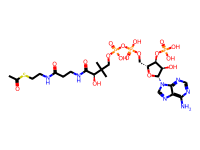
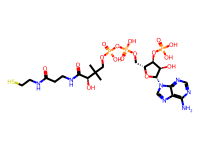
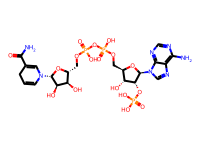
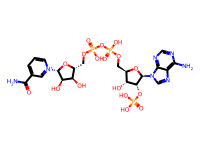
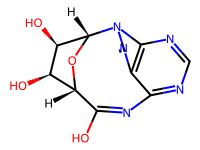
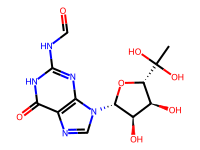
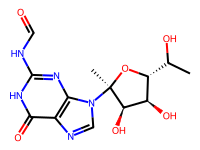
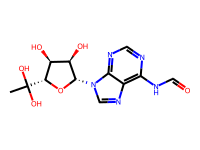
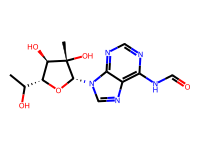
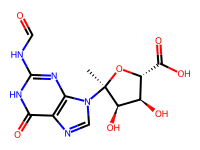
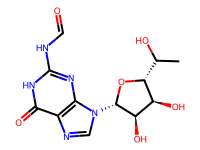
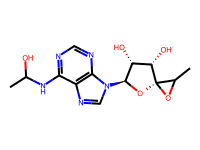
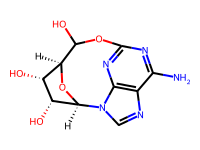
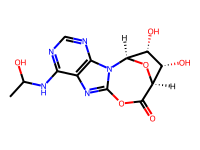
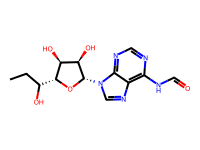
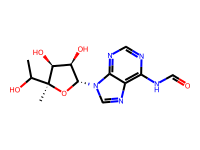
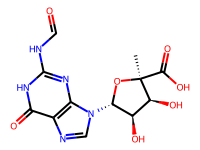
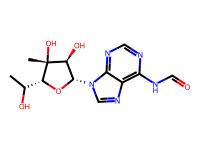
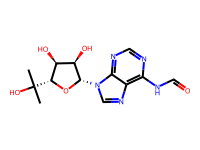
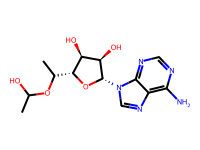

In [13]:
def smilesToImgHtml(smiles, imgSize=(200, 150)):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return ""
    buf = BytesIO()
    Draw.MolToImage(mol, size=imgSize).save(buf, format="PNG")
    encoded = base64.b64encode(buf.getvalue()).decode()
    return f'<img src="data:image/png;base64,{encoded}"/>'

targetCompound_DF["Structure"] = targetCompound_DF["Canonical_SMILES"].apply(smilesToImgHtml)

targetCompound_DF = targetCompound_DF[
    ["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "Structure", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
]

HTML(targetCompound_DF.to_html(escape=False, index=False))

In [14]:
def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

starterSmilesSet = set(targetCompound_DF["starter_Canonical_SMILES"].dropna().astype(str))
starterMols = [
    (canonicalizeSmiles(smi), Chem.MolFromSmiles(smi))
    for smi in starterSmilesSet
    if Chem.MolFromSmiles(smi) is not None
]

def isStarterDerived(smiles, starterMols):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return False
    return any(mol.HasSubstructMatch(starterMol) for _, starterMol in starterMols)

nBefore = len(targetCompound_DF)
targetCompound_DF = targetCompound_DF[
    targetCompound_DF["Canonical_SMILES"].apply(
        lambda smi: isStarterDerived(smi, starterMols)
    )
].reset_index(drop=True)
print(f"targetCompound_DF before starter filter : {nBefore:,}")
print(f"targetCompound_DF after starter filter  : {len(targetCompound_DF):,}")
print(f"Removed as non-starter derivatives      : {nBefore - len(targetCompound_DF):,}")

targetCompound_DF before starter filter : 20
targetCompound_DF after starter filter  : 20
Removed as non-starter derivatives      : 0


In [15]:
DORANETmoleculesDataDir = Path(DORANETmoleculesDataDir)

def canonicalizeSmilesCollection(x):
    if not isinstance(x, (set, list, tuple)):
        return []
    out = []
    for s in x:
        c = canonicalizeSmiles(s)
        if c is not None:
            out.append(c)
    return sorted(set(out))

def parseLiteralFromScript(text, varName):
    # captures lines like: varName = {...} / [...] / "..."
    m = re.search(rf"^\s*{re.escape(varName)}\s*=\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        return None
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

def parseHelpersFromScript(text):
    # Supports YAML-like line: helpers: ["O", ...]
    m = re.search(r"^\s*helpers\s*:\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        # fallback in case file uses python assignment: helpers = [...]
        return parseLiteralFromScript(text, "helpers")
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

allReproFiles = sorted(
    DORANETmoleculesDataDir.rglob("reproDoranetJob.py"),
    key=lambda p: str(p).lower()
)

records = []
for reproPath in allReproFiles:
    txt = reproPath.read_text(encoding="utf-8", errors="ignore")

    startersRaw = parseLiteralFromScript(txt, "starters")
    targetRaw = parseLiteralFromScript(txt, "target")
    maxAtomsRaw = parseLiteralFromScript(txt, "maxAtoms")
    generationsRaw = parseLiteralFromScript(txt, "generations")
    helpersRaw = parseHelpersFromScript(txt)

    records.append({
        "dirName": reproPath.parent.name,
        "starters": canonicalizeSmilesCollection(startersRaw),
        "target": canonicalizeSmilesCollection(targetRaw),
        "helpers": canonicalizeSmilesCollection(helpersRaw),   # NEW
        "maxAtoms": maxAtomsRaw if isinstance(maxAtomsRaw, dict) else None,
        "generations": int(generationsRaw) if generationsRaw is not None else None,
    })

targetCompoundDir_DF = pd.DataFrame(
    records,
    columns=["dirName", "starters", "target", "helpers", "maxAtoms", "generations"]  # NEW
)

print(f"Total DORAnet configuration files: {len(targetCompoundDir_DF)}")

# join key from first target smiles
targetCompoundDir_DF = targetCompoundDir_DF.copy()
targetCompoundDir_DF["targetSmiles"] = targetCompoundDir_DF["target"].apply(
    lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else None
)

colsToAdd = ["Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
targetCompoundDir_DF = targetCompoundDir_DF.merge(
    targetCompound_DF[colsToAdd].drop_duplicates(subset=["Canonical_SMILES"]),
    left_on="targetSmiles",
    right_on="Canonical_SMILES",
    how="left"
).drop(columns=["Canonical_SMILES"])

targetCompoundDir_DF = targetCompoundDir_DF.drop(columns=["targetSmiles"])
targetCompoundDir_DF = targetCompoundDir_DF.rename(columns={
    "starters": "starters_Canonical_SMILES",
    "target": "target_Canonical_SMILES",
    "helpers": "helpers_Canonical_SMILES",   
})

for c in ["starters_Canonical_SMILES", "target_Canonical_SMILES"]:
    targetCompoundDir_DF[c] = targetCompoundDir_DF[c].apply(
        lambda x: ".".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
    )

# Keep helpers as separate entries joined by comma (not dot)
targetCompoundDir_DF["helpers_Canonical_SMILES"] = targetCompoundDir_DF["helpers_Canonical_SMILES"].apply(
    lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
)

targetCompoundDir_DF = targetCompoundDir_DF.sort_values(
    by="pPotency_prediction", ascending=False
).reset_index(drop=True)

# safer path handling
outputPath = Path(DNADesignResultsDir) / "targetCompoundDir_DF.csv"
targetCompoundDir_DF.to_csv(outputPath, index=False)
targetCompoundDir_DF

Total DORAnet configuration files: 60


,dirName,starters_Canonical_SMILES,target_Canonical_SMILES,helpers_Canonical_SMILES,maxAtoms,generations,pPotency_prediction,pPotency_std,IC50 (µM)
0,high_pPotency_molecule_pathway1_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,6.156,0.476241,0.697981
1,high_pPotency_molecule_pathway1_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,6.156,0.476241,0.697981
2,high_pPotency_molecule_pathway1_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,6.156,0.476241,0.697981
3,high_pPotency_molecule_pathway2_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,5.989,0.473052,1.025573
4,high_pPotency_molecule_pathway2_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.989,0.473052,1.025573
5,high_pPotency_molecule_pathway2_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,5.989,0.473052,1.025573
6,high_pPotency_molecule_pathway3_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,5.729,0.473567,1.865382
7,high_pPotency_molecule_pathway3_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,5.729,0.473567,1.865382
8,high_pPotency_molecule_pathway3_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.729,0.473567,1.865382
9,high_pPotency_molecule_pathway4_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.638,0.472788,2.302842


## 2. Read the `reconstructed` pathways metadata for all `DORAnet` reactions

- go to the directory where pathway reconstruction DORAnet results are saved
- run this: `python pathwayReconstruction.py config.yaml`
- this will generate the csv file (`doranet_chain_reconstructed_pathway_steps_by_depth.csv`) with reconstructed pathways
- read the csv file for downstream processing

### Reconstruct pathway directly from multi generation DORAnet outputs

In [21]:
doranetMultiGenConfigPath = Path(DORANETmoleculesDataDir) / "config_doranet_multiGen.yaml"

with open(doranetMultiGenConfigPath, "r", encoding="utf-8") as f:
    doranetCfg = yaml.safe_load(f) or {}

outputDir = Path(doranetCfg.get("outputDir", ".")).expanduser()

# If outputDir is relative, first try relative to config location.
if not outputDir.is_absolute():
    outputDirFromConfigDir = (doranetMultiGenConfigPath.parent / outputDir).resolve()
    outputDirFromCwd = (Path.cwd() / outputDir).resolve()

    summaryCsvName = doranetCfg.get("summaryCsv", "job_summary.csv")
    if (outputDirFromConfigDir / summaryCsvName).exists():
        outputDir = outputDirFromConfigDir
    else:
        outputDir = outputDirFromCwd

summaryPath = Path(DORANETmoleculesDataDir) / "job_summary.csv"

if not summaryPath.exists():
    raise FileNotFoundError(f"Could not find job summary CSV: {summaryPath}")

jobSummaryDF = pd.read_csv(summaryPath)

print(f"Config file : {doranetMultiGenConfigPath}")
print(f"Output dir  : {outputDir}")
print(f"Summary CSV : {summaryPath}")
print(f"Jobs in summary: {len(jobSummaryDF):,}")

FileNotFoundError: Could not find job summary CSV: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/job_summary.csv

In [18]:
def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString):
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]


def sortedMoleculeString(moleculeString):
    mols = splitMoleculeString(moleculeString)
    return ".".join(sorted(mols))


def normalizeReactionSmiles(reactionSmiles):
    """
    Normalize a reaction SMILES by sorting reactant and product molecule strings.

    Input:
        A.B>>C.D

    Output:
        A.B>>C.D with molecules sorted on both sides.
    """
    if pd.isna(reactionSmiles) or ">>" not in str(reactionSmiles):
        return None

    reactants, products = str(reactionSmiles).split(">>", 1)

    reactantsNorm = sortedMoleculeString(reactants)
    productsNorm = sortedMoleculeString(products)

    return f"{reactantsNorm}>>{productsNorm}"


def extractFolderNum(name):
    match = re.search(r"pathway(\d+)", str(name))
    return int(match.group(1)) if match else -1


# Pathway *_pathways.txt parsing helpers

def splitPathwayBlocks(pathwaysTxtPath):
    if not Path(pathwaysTxtPath).exists():
        return []

    lines = Path(pathwaysTxtPath).read_text(encoding="utf-8").splitlines()

    blocks = []
    current = []

    for line in lines:
        if line.startswith("pathway number ") and current:
            blocks.append(current)
            current = [line]
        else:
            current.append(line)

    if current:
        blocks.append(current)

    blocks = [
        [x for x in block if str(x).strip()]
        for block in blocks
        if any(str(x).strip() for x in block)
    ]

    return blocks


def parsePathwayBlock(block):
    """
    Parse one block from DORAnet *_pathways.txt.

    Expected structure:
        pathway number 1
        place holder ...
        place holder ...
        place holder ...
        reaction SMILES stoichiometry [...]
        reaction SMILES, name, and enthalpy:
        rxn1
        rxn2
        ...
        name1
        name2
        ...
        dH1
        dH2
        ...
    """

    pathwayNumber = None
    for line in block:
        if line.startswith("pathway number "):
            pathwayNumber = str(line).replace("pathway number ", "").strip()
            break

    stoichList = []
    for line in block:
        prefix = "reaction SMILES stoichiometry "
        if line.startswith(prefix):
            payload = line[len(prefix):].strip()
            try:
                stoichList = ast.literal_eval(payload)
            except Exception:
                stoichList = []
            break

    marker = "reaction SMILES, name, and enthalpy:"
    try:
        markerIdx = block.index(marker)
    except ValueError:
        raise ValueError("Could not find reaction SMILES/name/enthalpy marker")

    payloadLines = [x.strip() for x in block[markerIdx + 1:] if str(x).strip()]

    if stoichList:
        numSteps = len(stoichList)
    else:
        if len(payloadLines) % 3 != 0:
            raise ValueError("Cannot infer number of steps from pathway block")
        numSteps = len(payloadLines) // 3
        stoichList = [None] * numSteps

    reactionSmilesList = payloadLines[:numSteps]
    reactionNameList = payloadLines[numSteps:2 * numSteps]
    enthalpyList = payloadLines[2 * numSteps:3 * numSteps]

    if len(reactionSmilesList) != numSteps:
        raise ValueError("Malformed pathway block: reaction count mismatch")

    return {
        "pathwayNumber": pathwayNumber,
        "numSteps": numSteps,
        "reactionSmilesList": reactionSmilesList,
        "reactionNameList": reactionNameList,
        "enthalpyList": enthalpyList,
        "stoichList": stoichList,
    }


def choosePathwayTxt(row):
    """
    Prefer exact-N pathway file generated by filterExactNumRxns.
    Fallback to default *_pathways.txt.
    """

    jobDir = Path(row["jobDir"])
    jobName = str(row["jobName"])
    generationRun = int(row["generationRun"])

    candidatePaths = []

    if "exactPathwaysTxt" in row and pd.notna(row["exactPathwaysTxt"]):
        p = Path(str(row["exactPathwaysTxt"]))
        if not p.is_absolute():
            p = jobDir / p
        candidatePaths.append(p)

    candidatePaths.extend([
        jobDir / f"{jobName}_pathways_exact{generationRun}.txt",
        jobDir / f"{jobName}_pathways.txt",
    ])

    for p in candidatePaths:
        if p.exists():
            return p

    return candidatePaths[0]


def parseReactionSmiles(reactionSmiles):
    if ">>" not in str(reactionSmiles):
        raise ValueError(f"Invalid reaction SMILES: {reactionSmiles}")

    reactants, products = str(reactionSmiles).split(">>", 1)
    return reactants, products


def parseStoich(stoichText):
    if stoichText is None or pd.isna(stoichText):
        return None, None

    parts = str(stoichText).split("$")
    reactantStoich = parts[0] if len(parts) > 0 else None
    productStoich = parts[1] if len(parts) > 1 else None

    return reactantStoich, productStoich


# Network JSON lookup helpers to recover reactionType

def parseNetworkReactionForLookup(rxnString):
    """
    Parse one reaction from *_network_pretreated.json.

    Expected DORAnet format:
        reactants > ruleName > thermo$reactantStoich$productStoich$reactionType > products
    """

    parts = str(rxnString).split(">")

    if len(parts) != 4:
        return None

    reactants, ruleName, metaBlock, products = parts

    metaParts = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    reactionSmiles = f"{reactants}>>{products}"
    normalizedReactionSmiles = normalizeReactionSmiles(reactionSmiles)

    return {
        "reactionSMILES": reactionSmiles,
        "normalizedReactionSMILES": normalizedReactionSmiles,
        "ruleName": ruleName,
        "thermo": thermo,
        "reactantStoich": reactantStoich,
        "productStoich": productStoich,
        "reactionType": reactionType,
        "rawNetworkReactionString": str(rxnString),
    }


def buildNetworkReactionLookup(networkJsonPath):
    """
    Build lookup dictionaries from *_network_pretreated.json.

    Matching priority later:
        1. normalized reaction SMILES + ruleName
        2. normalized reaction SMILES only
    """

    networkJsonPath = Path(networkJsonPath)

    lookupByReactionAndRule = {}
    lookupByReactionOnly = {}

    if not networkJsonPath.exists():
        return lookupByReactionAndRule, lookupByReactionOnly

    try:
        with open(networkJsonPath, "r", encoding="utf-8") as f:
            reactionList = json.load(f)
    except Exception:
        return lookupByReactionAndRule, lookupByReactionOnly

    if not isinstance(reactionList, list):
        return lookupByReactionAndRule, lookupByReactionOnly

    for rxnString in reactionList:
        parsed = parseNetworkReactionForLookup(rxnString)

        if parsed is None:
            continue

        normRxn = parsed["normalizedReactionSMILES"]
        ruleName = parsed["ruleName"]

        if normRxn is None:
            continue

        lookupByReactionAndRule[(normRxn, ruleName)] = parsed

        if normRxn not in lookupByReactionOnly:
            lookupByReactionOnly[normRxn] = parsed

    return lookupByReactionAndRule, lookupByReactionOnly


def lookupNetworkReactionMetadata(reactionSmiles, ruleName, lookupByReactionAndRule, lookupByReactionOnly):
    """
    Match a pathway reaction back to *_network_pretreated.json.
    """

    normalizedReactionSmiles = normalizeReactionSmiles(reactionSmiles)

    if normalizedReactionSmiles is None:
        return {
            "reactionType": "",
            "rawNetworkReactionString": "",
            "networkMatchStatus": "invalid_reaction_smiles",
        }

    match = lookupByReactionAndRule.get((normalizedReactionSmiles, ruleName))

    if match is not None:
        out = dict(match)
        out["networkMatchStatus"] = "matched_by_reaction_and_rule"
        return out

    match = lookupByReactionOnly.get(normalizedReactionSmiles)

    if match is not None:
        out = dict(match)
        out["networkMatchStatus"] = "matched_by_reaction_only"
        return out

    return {
        "reactionType": "",
        "rawNetworkReactionString": "",
        "networkMatchStatus": "no_network_match",
    }

def extractFullReactionSmiles(rawNetworkReactionString):
    if not rawNetworkReactionString or not str(rawNetworkReactionString).strip():
        return None
    parts = str(rawNetworkReactionString).split(">")
    if len(parts) != 4:
        return None
    return f"{parts[0].strip()}>>{parts[3].strip()}"

def identifyCofactors(fullReactionSMILES, simplifiedReactionSMILES, helperSet, starterSet, targetSMILES):
    if not fullReactionSMILES or ">>" not in str(fullReactionSMILES):
        return "", ""
    if not simplifiedReactionSMILES or ">>" not in str(simplifiedReactionSMILES):
        return "", ""
    fullR,  fullP = str(fullReactionSMILES).split(">>", 1)
    simpR,  simpP = str(simplifiedReactionSMILES).split(">>", 1)
    fullReactantSet = {s.strip() for s in fullR.split(".") if s.strip()}
    simpReactantSet = {s.strip() for s in simpR.split(".") if s.strip()}
    fullProductSet  = {s.strip() for s in fullP.split(".") if s.strip()}
    simpProductSet  = {s.strip() for s in simpP.split(".") if s.strip()}
    knownMols = helperSet | starterSet | {targetSMILES}
    cofactorReactants = ";".join(sorted(fullReactantSet - simpReactantSet - knownMols))
    cofactorProducts  = ";".join(sorted(fullProductSet  - simpProductSet  - knownMols))
    return cofactorReactants, cofactorProducts


starterSet = set(doranetCfg.get("starters", []))
helperSet  = set(doranetCfg.get("helpers",  []))

records     = []
parseErrors = []
networkLookupCache = {}

validJobsDF = jobSummaryDF.copy()
if "status" in validJobsDF.columns:
    validJobsDF = validJobsDF[validJobsDF["status"].eq("ok")].copy()

for _, jobRow in tqdm(validJobsDF.iterrows(), total=len(validJobsDF), desc="Reading DORAnet pathway files"):
    jobName       = str(jobRow["jobName"])
    jobDir        = Path(jobRow["jobDir"])
    dirName       = jobDir.name
    generationRun = int(jobRow["generationRun"])
    targetSMILES  = str(jobRow["targetSmiles"])

    pathwayTxtPath  = choosePathwayTxt(jobRow)
    networkJsonPath = jobDir / f"{jobName}_network_pretreated.json"

    if jobName not in networkLookupCache:
        networkLookupCache[jobName] = buildNetworkReactionLookup(networkJsonPath)
    lookupByReactionAndRule, lookupByReactionOnly = networkLookupCache[jobName]

    try:
        blocks = splitPathwayBlocks(pathwayTxtPath)

        for blockIdx, block in enumerate(blocks, start=1):
            parsed = parsePathwayBlock(block)

            numSteps      = parsed["numSteps"]
            pathwayNumber = parsed["pathwayNumber"] or str(blockIdx)
            routeId = (
                f"{jobName}_route_{int(pathwayNumber):06d}"
                if str(pathwayNumber).isdigit()
                else f"{jobName}_route_{blockIdx:06d}"
            )

            reconstructedPathwayString = "  ||  ".join(parsed["reactionSmilesList"])

            for stepIdx, reactionSmiles in enumerate(parsed["reactionSmilesList"], start=1):
                reactants, products = parseReactionSmiles(reactionSmiles)

                ruleName             = parsed["reactionNameList"][stepIdx - 1] if stepIdx - 1 < len(parsed["reactionNameList"]) else ""
                thermoFromPathwayTxt = parsed["enthalpyList"][stepIdx - 1]     if stepIdx - 1 < len(parsed["enthalpyList"])     else ""
                stoichText           = parsed["stoichList"][stepIdx - 1]       if stepIdx - 1 < len(parsed["stoichList"])       else None

                reactantStoichFromTxt, productStoichFromTxt = parseStoich(stoichText)

                networkMatch = lookupNetworkReactionMetadata(
                    reactionSmiles=reactionSmiles,
                    ruleName=ruleName,
                    lookupByReactionAndRule=lookupByReactionAndRule,
                    lookupByReactionOnly=lookupByReactionOnly,
                )

                reactionType             = networkMatch.get("reactionType", "")
                rawNetworkReactionString = networkMatch.get("rawNetworkReactionString", "")
                networkMatchStatus       = networkMatch.get("networkMatchStatus", "")

                thermo         = thermoFromPathwayTxt if thermoFromPathwayTxt not in ["", None] else networkMatch.get("thermo", "")
                reactantStoich = reactantStoichFromTxt if reactantStoichFromTxt not in ["", None] else networkMatch.get("reactantStoich", None)
                productStoich  = productStoichFromTxt  if productStoichFromTxt  not in ["", None] else networkMatch.get("productStoich",  None)

                fullReactionSMILES = extractFullReactionSmiles(rawNetworkReactionString)

                cofactorReactants, cofactorProducts = identifyCofactors(
                    fullReactionSMILES, reactionSmiles, helperSet, starterSet, targetSMILES
                )

                activeReactionSMILES     = fullReactionSMILES if fullReactionSMILES else reactionSmiles
                activeReactants, activeProducts = parseReactionSmiles(activeReactionSMILES)
                reactantMols = set(splitMoleculeString(activeReactants))
                productMols  = set(splitMoleculeString(activeProducts))

                records.append({
                    "dirName"                   : dirName,
                    "jobName"                   : jobName,
                    "sourceFolderNum"           : extractFolderNum(jobName),
                    "sourceDirectory"           : dirName,
                    "sourceDirectoryPath"       : str(jobDir),
                    "sourceJsonName"            : f"{jobName}_network_pretreated.json",
                    "sourceJsonPath"            : str(networkJsonPath),
                    "sourcePathwaysTxtPath"     : str(pathwayTxtPath),
                    "routeId"                   : routeId,
                    "routeNumberInFile"         : pathwayNumber,
                    "generationRun"             : generationRun,
                    "searchDepthUsed"           : generationRun,
                    "step"                      : stepIdx,
                    "numSteps"                  : numSteps,
                    "starterSMILES"             : ";".join(sorted(starterSet)),
                    "targetSMILES"              : targetSMILES,
                    "reactants"                 : activeReactants,
                    "products"                  : activeProducts,
                    "reactionString"            : f"{activeReactants} >> {activeProducts}",
                    "reactionSMILES"            : activeReactionSMILES,
                    "simplifiedReactionSMILES"  : reactionSmiles,
                    "fullReactionSMILES"        : fullReactionSMILES or "",
                    "reconstructedPathwayString": reconstructedPathwayString,
                    "cofactorReactants"         : cofactorReactants,
                    "cofactorProducts"          : cofactorProducts,
                    "hasCofactors"              : bool(cofactorReactants or cofactorProducts),
                    "ruleName"                  : ruleName,
                    "thermo"                    : thermo,
                    "reactantStoich"            : reactantStoich,
                    "productStoich"             : productStoich,
                    "reactionType"              : reactionType,
                    "rawNetworkReactionString"  : rawNetworkReactionString,
                    "networkMatchStatus"        : networkMatchStatus,
                    "numReactantMolecules"      : len(reactantMols),
                    "numProductMolecules"       : len(productMols),
                    "starterInReactants"        : bool(reactantMols & starterSet),
                    "targetInProducts"          : targetSMILES in productMols,
                    "isReconstructedPathwayStep": True,
                    "routeStepId"               : f"{routeId}_step_{stepIdx:02d}",
                })

    except Exception as exc:
        parseErrors.append({
            "jobName"        : jobName,
            "jobDir"         : str(jobDir),
            "generationRun"  : generationRun,
            "targetSMILES"   : targetSMILES,
            "pathwayTxtPath" : str(pathwayTxtPath),
            "networkJsonPath": str(networkJsonPath),
            "error"          : str(exc),
        })


reconstructedPathwaysDF = (
    pd.DataFrame(records)
    .sort_values(["sourceFolderNum", "generationRun", "routeId", "step"])
    .reset_index(drop=True)
)

fullPathwayPerRoute = (
    reconstructedPathwaysDF
    .sort_values(["routeId", "step"])
    .groupby("routeId", as_index=False)["fullReactionSMILES"]
    .apply(lambda g: "  ||  ".join(g.dropna()))
    .rename(columns={"fullReactionSMILES": "fullReconstructedPathwayString"})
)
reconstructedPathwaysDF = reconstructedPathwaysDF.merge(fullPathwayPerRoute, on="routeId", how="left")

parseErrorsDF = pd.DataFrame(parseErrors)

print(f"Reconstructed pathway step rows : {len(reconstructedPathwaysDF):,}")
print(f"Unique routes                   : {reconstructedPathwaysDF['routeId'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Unique job folders              : {reconstructedPathwaysDF['dirName'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Unique target SMILES            : {reconstructedPathwaysDF['targetSMILES'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Steps with cofactors            : {reconstructedPathwaysDF['hasCofactors'].sum():,}")
print(f"Parse errors                    : {len(parseErrorsDF):,}")

if not reconstructedPathwaysDF.empty:
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())
    print("\nNetwork match status:")
    print(reconstructedPathwaysDF["networkMatchStatus"].value_counts(dropna=False).to_string())
    print("\nTop cofactor reactants:")
    print(
        reconstructedPathwaysDF["cofactorReactants"]
        .replace("", pd.NA).dropna()
        .str.split(";").explode()
        .value_counts().head(15).to_string()
    )

reconstructedPathwaysDF

NameError: name 'jobSummaryDF' is not defined

### Print unique `target SMILES`

In [ ]:
if not reconstructedPathwaysDF.empty:
    # Per-target route counts broken down by step depth
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())
    
    stepCountsDF = (
        reconstructedPathwaysDF
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF["totalRoutes"] = stepCountsDF.sum(axis=1)
    stepCountsDF["pPotency_prediction"] = stepCountsDF.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF = stepCountsDF.sort_values("totalRoutes", ascending=False).reset_index()

print("\nTarget SMILES found:")
stepCountsDF

In [ ]:
# CONFIG
molsPerRow  = 3
subImgSize  = (300, 220)
labelHeight = 50

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

labelFont = loadFont(16)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeMolPanel(smiles, pPotency, rank, subImageSize=(300, 220), labelHeight=50):
    canon = canonSmiles(str(smiles))
    mol   = Chem.MolFromSmiles(canon)
    if mol is None:
        return None
    molImg = Draw.MolToImage(mol, size=subImageSize).convert("RGB")
    pLabel = f"pPotency = {pPotency:.4f}" if pPotency is not None and not pd.isna(pPotency) else "pPotency = N/A"
    label  = f"#{rank}  {pLabel}"
    banner = Image.new("RGB", (molImg.width, labelHeight), "#f7f7f7")
    centeredText(ImageDraw.Draw(banner), label, molImg.width, (labelHeight - 18) // 2, labelFont, "#222222")
    combined = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    combined.paste(molImg,  (0, 0))
    combined.paste(banner,  (0, molImg.height))
    return combined

def renderGridWithLabels(df, smileCol, labelCol, molsPerRow=3, subImageSize=(300, 220), labelHeight=50):
    panels = []
    for rank, (_, row) in enumerate(df.iterrows(), start=1):
        panel = makeMolPanel(row[smileCol], row[labelCol], rank, subImageSize, labelHeight)
        if panel is not None:
            panels.append(panel)

    if not panels:
        print("No valid structures to display.")
        return

    panelW  = panels[0].width
    panelH  = panels[0].height
    gap     = 10
    nRows   = (len(panels) + molsPerRow - 1) // molsPerRow
    canvasW = molsPerRow * panelW + (molsPerRow - 1) * gap
    canvasH = nRows * panelH + (nRows - 1) * gap
    canvas  = Image.new("RGB", (canvasW, canvasH), "white")

    for idx, panel in enumerate(panels):
        r = idx // molsPerRow
        c = idx  % molsPerRow
        canvas.paste(panel, (c * (panelW + gap), r * (panelH + gap)))

    display(canvas)

renderGridWithLabels(
    df           = stepCountsDF,
    smileCol     = "targetSMILES",
    labelCol     = "pPotency_prediction",
    molsPerRow   = molsPerRow,
    subImageSize = subImgSize,
    labelHeight  = labelHeight,
)

### select a compund from `stepCountsDF`

In [ ]:
stepCountsDF_selectedCompound = 0   # 0-indexed: 0 = most routes, 1 = second, 2 = third

### Filter one compound which has maximum number of pathways for downstream `DNA designs`

In [ ]:
bestSmiles = stepCountsDF.loc[stepCountsDF_selectedCompound, "targetSMILES"]

reconstructedPathwaysDF_OneCompound = (
    reconstructedPathwaysDF[reconstructedPathwaysDF["targetSMILES"] == bestSmiles]
    .reset_index(drop=True)
)

print(f"Selected target (rank {stepCountsDF_selectedCompound + 1}) : {bestSmiles}")
print(f"  pPotency_prediction : {stepCountsDF.loc[stepCountsDF_selectedCompound, 'pPotency_prediction']:.4f}")
print(f"  Routes              : {reconstructedPathwaysDF_OneCompound['routeId'].nunique():,}")
print(f"  Step rows           : {len(reconstructedPathwaysDF_OneCompound):,}")

reconstructedPathwaysDF_OneCompound

In [ ]:
completeRouteLevelDF = (
    reconstructedPathwaysDF_OneCompound
    .sort_values(["dirName", "routeId", "step"])
    .groupby("routeId", as_index=False)
    .agg(
        dirName=("dirName", "first"),
        jobName=("jobName", "first"),
        sourceFolderNum=("sourceFolderNum", "first"),
        generationRun=("generationRun", "first"),
        numSteps=("numSteps", "first"),
        searchDepthUsed=("searchDepthUsed", "first"),
        starterSMILES=("starterSMILES", "first"),
        targetSMILES=("targetSMILES", "first"),
        reconstructedPathwayString=("reconstructedPathwayString", "first"),
    )
)

starterTargetPathwayCountsDF = (
    completeRouteLevelDF
    .pivot_table(
        index=["dirName", "jobName", "generationRun", "starterSMILES", "targetSMILES"],
        columns="numSteps",
        values="routeId",
        aggfunc="nunique",
        fill_value=0,
    )
    .rename(columns={
        1: "numOneStepPathways",
        2: "numTwoStepPathways",
        3: "numThreeStepPathways",
    })
    .reset_index()
)

for c in ["numOneStepPathways", "numTwoStepPathways", "numThreeStepPathways"]:
    if c not in starterTargetPathwayCountsDF.columns:
        starterTargetPathwayCountsDF[c] = 0

starterTargetPathwayCountsDF["totalStarterToTargetPathways"] = (
    starterTargetPathwayCountsDF["numOneStepPathways"]
    + starterTargetPathwayCountsDF["numTwoStepPathways"]
    + starterTargetPathwayCountsDF["numThreeStepPathways"]
)

starterTargetPathwayCountsDF = (
    starterTargetPathwayCountsDF
    .sort_values("totalStarterToTargetPathways", ascending=False)
    .reset_index(drop=True)
)

print(f"Total reaction-step rows             : {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Complete starter --> target pathways: {len(completeRouteLevelDF):,}")
print(f"Job folders reached starter --> target: {starterTargetPathwayCountsDF['dirName'].nunique():,}")

starterTargetPathwayCountsDF

### Show `starter` and `target` compound

In [ ]:
# Extract unique starter and target SMILES from the selected compound's pathways
starterSmilesList = [
    s.strip()
    for raw in reconstructedPathwaysDF_OneCompound["starterSMILES"].dropna().unique()
    for s in raw.split(";") if s.strip()
]
targetSmilesList = [bestSmiles]

starterMols = [(Chem.MolFromSmiles(s), f"Starter: {s[:40]}") for s in starterSmilesList]
targetMols  = [(Chem.MolFromSmiles(s), f"Target: {s[:40]}")  for s in targetSmilesList]

allMols    = [m for m, _ in starterMols + targetMols if m is not None]
allLabels  = [l for m, l in starterMols + targetMols if m is not None]

img = Draw.MolsToGridImage(
    allMols,
    molsPerRow=len(allMols),
    subImgSize=(350, 280),
    legends=allLabels,
)
display(img)

### Show some example `reaction pathways`

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

# CONFIG
numToDisplay   = 3
selectedRoutes = {
    1: [0, 1],
    2: [0, 1],
    3: [0, 1],
}
subImgSize = (280, 210)

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def getMolLabel(smi, canonStarterSet, canonTargetSmi, side="reactant"):
    canon = canonSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    return "Reactant" if side == "reactant" else "Product"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg      = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    labelBanner = Image.new("RGB", (molImg.width, 34), "#f0f0f0")
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, "#333333")
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox         = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                             panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    reactantSmiles = (
        [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonSmiles(s) in canonStarterSet]
        + [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonSmiles(s) not in canonStarterSet]
    )
    productSmiles = (
        [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonSmiles(s) != canonTargetSmi]
        + [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonSmiles(s) == canonTargetSmi]
    )
    reactantImgs = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="reactant"), subImageSize)
        for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="product"), subImageSize)
        for s in productSmiles]  if img is not None]
    if not reactantImgs or not productImgs:
        return None
    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap
    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

def buildRouteImage(rowData, numSteps, subImageSize, bannerWidth):
    canonStarterSet = {canonSmiles(s) for s in splitStarters(rowData.get("starterSMILES", ""))}
    canonTargetSmi  = canonSmiles(rowData.get("targetSMILES", ""))
    forwardSteps    = reorderStepsForward(
        splitPathway(rowData.get("reconstructedPathwayString", np.nan)), canonStarterSet
    )
    panelBlocks = [makeTextBanner(
        f"{rowData['dirName']}  |  Route: {rowData['routeId']}  |  Gen: {rowData['generationRun']}  |  Steps: {numSteps}",
        bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7",
    )]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                                        panelTitle=f"Reaction step {stepIdx} of {numSteps}",
                                        subImageSize=subImageSize)
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

# Collapse step-level DF to route-level
routeLevelDF = (
    reconstructedPathwaysDF_OneCompound
    .groupby("routeId", as_index=False)
    .agg(
        dirName                    = ("dirName",                    "first"),
        jobName                    = ("jobName",                    "first"),
        generationRun              = ("generationRun",              "first"),
        numSteps                   = ("numSteps",                   "first"),
        starterSMILES              = ("starterSMILES",              "first"),
        targetSMILES               = ("targetSMILES",               "first"),
        reconstructedPathwayString = ("reconstructedPathwayString", "first"),
    )
    .sort_values(["numSteps", "routeId"])
    .reset_index(drop=True)
)

for numSteps, groupDF in routeLevelDF.groupby("numSteps"):
    availableRoutes = groupDF.reset_index(drop=True)
    indices         = selectedRoutes.get(numSteps, list(range(numToDisplay)))
    validIndices    = [i for i in indices if i < len(availableRoutes)]

    print(f"\n{numSteps}-step pathways: {len(availableRoutes):,} available, displaying {len(validIndices):,}")
    if not validIndices:
        print(f"  No valid indices for {numSteps}-step — check selectedRoutes config.")
        continue

    for rank, idx in enumerate(validIndices, start=1):
        rowData    = availableRoutes.loc[idx]
        routeImage = buildRouteImage(rowData, numSteps, subImgSize, bannerWidth=1800)
        if routeImage is not None:
            print(f"  [{rank}/{len(validIndices)}] Route: {rowData['routeId']}")
            display(routeImage)

print("\nDone.")

In [ ]:
from rdkit.Chem import rdFMCS, AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem
from joblib import Parallel, delayed
from tqdm import tqdm

# CONFIG
mcsCoverageThreshold = 0.70
tanimotoThreshold    = 0.40
mcsTimeout           = 3        # reduced from 10 — most real matches resolve in <1s
tanimotoPreFilter    = 0.15     # skip MCS entirely if Tanimoto < this
nJobs                = 8        # cores to use

# Pre-compute fingerprints once per unique SMILES — keyed by canonical SMILES
def buildFingerprintCache(smilesList):
    fpCache = {}
    for smi in smilesList:
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            fpCache[smi] = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return fpCache

def getMurckoScaffold(mol):
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold) if scaffold else ""
    except Exception:
        return ""

def computeDerivativeMetrics(smilesRef, smilesQuery, refLabel, fpCache):
    molRef   = Chem.MolFromSmiles(str(smilesRef))
    molQuery = Chem.MolFromSmiles(str(smilesQuery))
    if molRef is None or molQuery is None:
        return None

    nAtomsRef   = molRef.GetNumHeavyAtoms()
    nAtomsQuery = molQuery.GetNumHeavyAtoms()

    # Fast Tanimoto pre-filter — skip expensive MCS if molecules are very dissimilar
    fpRef   = fpCache.get(smilesRef)
    fpQuery = fpCache.get(smilesQuery)
    tanimoto = round(DataStructs.TanimotoSimilarity(fpRef, fpQuery), 3) if (fpRef and fpQuery) else 0.0

    if tanimoto < tanimotoPreFilter:
        return {
            "refLabel": refLabel, "smilesRef": smilesRef, "smilesQuery": smilesQuery,
            "nAtomsRef": nAtomsRef, "nAtomsQuery": nAtomsQuery,
            "atomDiff": nAtomsQuery - nAtomsRef,
            "refInQuery": False, "queryInRef": False,
            "mcsNumAtoms": 0, "mcsCoverageRef": 0.0, "mcsCoverageQuery": 0.0, "mcsCoverageMin": 0.0,
            "mcsSmarts": "", "tanimoto": tanimoto,
            "scaffoldRef": "", "scaffoldQuery": "", "sharedScaffold": False,
            "isDerivative": False, "supportingEvidence": False,
            "derivativeReason": "skipped: Tanimoto below pre-filter",
        }

    # Substructure check
    refInQuery = molQuery.HasSubstructMatch(molRef)
    queryInRef = molRef.HasSubstructMatch(molQuery)

    # MCS
    mcsResult        = rdFMCS.FindMCS(
        [molRef, molQuery],
        atomCompare=rdFMCS.AtomCompare.CompareElements,
        bondCompare=rdFMCS.BondCompare.CompareOrder,
        ringMatchesRingOnly=True,
        completeRingsOnly=True,
        timeout=mcsTimeout,
    )
    mcsAtoms         = mcsResult.numAtoms
    mcsSmarts        = mcsResult.smartsString
    mcsCoverageRef   = round(mcsAtoms / nAtomsRef,   3) if nAtomsRef   > 0 else 0.0
    mcsCoverageQuery = round(mcsAtoms / nAtomsQuery, 3) if nAtomsQuery > 0 else 0.0
    mcsCoverageMin   = min(mcsCoverageRef, mcsCoverageQuery)

    # Murcko scaffold
    scaffoldRef    = getMurckoScaffold(molRef)
    scaffoldQuery  = getMurckoScaffold(molQuery)
    sharedScaffold = (scaffoldRef == scaffoldQuery and scaffoldRef != "")

    strongDerivative   = refInQuery or (mcsCoverageMin >= mcsCoverageThreshold)
    supportingEvidence = tanimoto >= tanimotoThreshold or sharedScaffold
    isDerivative       = strongDerivative

    derivativeReason = []
    if refInQuery:
        derivativeReason.append("ref is substructure of query")
    if queryInRef:
        derivativeReason.append("query is substructure of ref")
    if mcsCoverageMin >= mcsCoverageThreshold:
        derivativeReason.append(f"MCS covers {mcsCoverageMin*100:.0f}% of smaller mol")
    if tanimoto >= tanimotoThreshold:
        derivativeReason.append(f"Tanimoto={tanimoto:.2f}")
    if sharedScaffold:
        derivativeReason.append("shared Murcko scaffold")

    return {
        "refLabel"           : refLabel,
        "smilesRef"          : smilesRef,
        "smilesQuery"        : smilesQuery,
        "nAtomsRef"          : nAtomsRef,
        "nAtomsQuery"        : nAtomsQuery,
        "atomDiff"           : nAtomsQuery - nAtomsRef,
        "refInQuery"         : refInQuery,
        "queryInRef"         : queryInRef,
        "mcsNumAtoms"        : mcsAtoms,
        "mcsCoverageRef"     : mcsCoverageRef,
        "mcsCoverageQuery"   : mcsCoverageQuery,
        "mcsCoverageMin"     : mcsCoverageMin,
        "mcsSmarts"          : mcsSmarts,
        "tanimoto"           : tanimoto,
        "scaffoldRef"        : scaffoldRef,
        "scaffoldQuery"      : scaffoldQuery,
        "sharedScaffold"     : sharedScaffold,
        "isDerivative"       : isDerivative,
        "supportingEvidence" : supportingEvidence,
        "derivativeReason"   : " | ".join(derivativeReason) if derivativeReason else "none",
    }


def analyzeDerivativeRelationships(reconstructedPathwaysDF_OneCompound):

    # Step 1: collect all unique (smilesRef, smilesQuery, refLabel) pairs
    # and the route metadata they belong to — no computation yet
    pairToRoutes = {}  # (smilesRef, smilesQuery, refLabel) → list of (routeId, numSteps)

    for routeId, routeDF in reconstructedPathwaysDF_OneCompound.groupby("routeId"):
        targetSmi   = canonSmiles(str(routeDF["targetSMILES"].iloc[0]))
        starterRaw  = str(routeDF["starterSMILES"].iloc[0])
        starterList = [canonSmiles(s.strip()) for s in starterRaw.split(";") if s.strip()]
        numSteps    = int(routeDF["numSteps"].iloc[0])

        uniqueReactants = set()
        for reactantStr in routeDF["reactants"].dropna():
            for smi in str(reactantStr).split("."):
                smi = smi.strip()
                if smi:
                    uniqueReactants.add(canonSmiles(smi))

        for starterSmi in starterList:
            key = (starterSmi, targetSmi, "starter")
            pairToRoutes.setdefault(key, []).append((routeId, numSteps))

        canonStarterSet = set(starterList)
        for reactantSmi in uniqueReactants:
            if reactantSmi in canonStarterSet or reactantSmi == targetSmi:
                continue
            key = (reactantSmi, targetSmi, "reactant")
            pairToRoutes.setdefault(key, []).append((routeId, numSteps))

    uniquePairs = list(pairToRoutes.keys())
    print(f"Unique (ref, query) pairs to evaluate : {len(uniquePairs):,}")
    print(f"Redundant computations avoided        : {sum(len(v) for v in pairToRoutes.values()) - len(uniquePairs):,}")

    # Step 2: build fingerprint cache for all unique SMILES
    allSmiles = {smi for pair in uniquePairs for smi in (pair[0], pair[1])}
    fpCache   = buildFingerprintCache(allSmiles)
    print(f"Fingerprints pre-computed             : {len(fpCache):,}")

    # Step 3: parallel evaluation — one job per unique pair
    results = Parallel(n_jobs=nJobs, prefer="threads")(
        delayed(computeDerivativeMetrics)(ref, query, label, fpCache)
        for ref, query, label in tqdm(uniquePairs, desc="Computing metrics")
    )

    # Step 4: expand results back to per-route rows
    records = []
    for (ref, query, label), metrics in zip(uniquePairs, results):
        if metrics is None:
            continue
        for routeId, numSteps in pairToRoutes[(ref, query, label)]:
            row = dict(metrics)
            row["routeId"]  = routeId
            row["numSteps"] = numSteps
            records.append(row)

    return (
        pd.DataFrame(records)
        .sort_values(["isDerivative", "mcsCoverageMin", "tanimoto"], ascending=[False, False, False])
        .reset_index(drop=True)
    )


derivativeDF = analyzeDerivativeRelationships(reconstructedPathwaysDF_OneCompound)

starterVsTarget  = derivativeDF[derivativeDF["refLabel"] == "starter"]
reactantVsTarget = derivativeDF[derivativeDF["refLabel"] == "reactant"]

print("\nStarter vs Target")
print(f"  Routes analysed      : {starterVsTarget['routeId'].nunique():,}")
print(f"  Target is derivative : {starterVsTarget['isDerivative'].sum():,} / {len(starterVsTarget):,}")
print(f"  Mean MCS coverage    : {starterVsTarget['mcsCoverageMin'].mean():.1%}")
print(f"  Mean Tanimoto        : {starterVsTarget['tanimoto'].mean():.3f}")
print(f"  Shared scaffold      : {starterVsTarget['sharedScaffold'].sum():,}")

print("\nReactant vs Target")
print(f"  Unique reactants     : {reactantVsTarget['smilesRef'].nunique():,}")
print(f"  Target is derivative : {reactantVsTarget['isDerivative'].sum():,} / {len(reactantVsTarget):,}")
print(f"  Mean MCS coverage    : {reactantVsTarget['mcsCoverageMin'].mean():.1%}")
print(f"  Mean Tanimoto        : {reactantVsTarget['tanimoto'].mean():.3f}")

print("\nDerivation reasons (starter vs target)")
print(starterVsTarget["derivativeReason"].value_counts(dropna=False).to_string())

derivativeDF[[
    "routeId", "numSteps", "refLabel",
    "nAtomsRef", "nAtomsQuery", "atomDiff",
    "refInQuery", "mcsCoverageMin", "tanimoto",
    "sharedScaffold", "isDerivative", "derivativeReason"
]]

### `Thermodynamic` feasibility check

### Keep only `enzymatic` DORAnet reactions

In [ ]:
enzymaticReactionDF = reconstructedPathwaysDF_OneCompound[
    reconstructedPathwaysDF_OneCompound["reactionType"].astype(str).str.lower().str.contains(
        "enzyme|enzymatic|bio|biological",
        na=False
    )
].copy()

print(f"Total reactions: {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Likely enzymatic reactions: {len(enzymaticReactionDF):,}")

enzymaticReactionDF.head()

### Generate a list of all `Helper` and `Intermediate` molecules

## 2. Use `DORA-XGB` to get feasibility score

In [ ]:
reactionDF_DORAXGB = enzymaticReactionDF.copy()
#reactionDF_DORAXGB = enzymaticReactionDF.head(50).copy()

# Clean reaction string for model input
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

def getFeasibilityScoresAndLabels(rxnStr):
    return pd.Series({
        "feasibilityScore_rule1": by_desc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule1": by_desc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule2": by_asc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule2": by_asc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule3": add_concat_model.predict_proba(rxnStr),
        "feasibilityLabel_rule3": add_concat_model.predict_label(rxnStr),

        "feasibilityScore_rule4": add_subtract_model.predict_proba(rxnStr),
        "feasibilityLabel_rule4": add_subtract_model.predict_label(rxnStr),
    })


reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

reactionDF_DORAXGB[
    [
        "feasibilityScore_rule1",
        "feasibilityLabel_rule1",
        "feasibilityScore_rule2",
        "feasibilityLabel_rule2",
        "feasibilityScore_rule3",
        "feasibilityLabel_rule3",
        "feasibilityScore_rule4",
        "feasibilityLabel_rule4",
    ]
] = reactionDF_DORAXGB["rxn_str"].apply(getFeasibilityScoresAndLabels)

reactionDF_DORAXGB.head()

### Keep only `high feasible` reactions

In [ ]:
# Choose which feasibility label to use
feasibilityLabel = "feasibilityLabel_rule3"   # <- change to rule2/rule3/rule4 as needed (Yash's paper says rule3 is the best one)
targetValue = 1                               # <- change if you want a different label value

# Optional safety check
validLabels = [
    "feasibilityLabel_rule1",
    "feasibilityLabel_rule2",
    "feasibilityLabel_rule3",
    "feasibilityLabel_rule4",
]
if feasibilityLabel not in validLabels:
    raise ValueError(f"Invalid feasibilityLabel: {feasibilityLabel}. Choose from {validLabels}")

if feasibilityLabel not in reactionDF_DORAXGB.columns:
    raise KeyError(f"Column '{feasibilityLabel}' not found in reactionDF_DORAXGB")

In [ ]:
reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ]
    .sort_values(by=feasibilityLabel, ascending=False)
    .reset_index(drop=True)
)

uniqueReactantStrings_high = set(reactionDF_DORAXGB_highFeasibility["reactants"])
uniqueProductStrings_high = set(reactionDF_DORAXGB_highFeasibility["products"])

uniqueReactantMolecules_high = {
    mol.strip()
    for reactants in reactionDF_DORAXGB_highFeasibility["reactants"]
    for mol in str(reactants).split(".")
    if mol.strip()
}

uniqueProductMolecules_high = {
    mol.strip()
    for products in reactionDF_DORAXGB_highFeasibility["products"]
    for mol in str(products).split(".")
    if mol.strip()
}

print(f"Feasibility label used: {feasibilityLabel} == {targetValue}")
print(f"Number of total reactions: {len(reactionDF_DORAXGB)}")
print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")
print(f"Number of unique reactant strings: {len(uniqueReactantStrings_high)}")
print(f"Number of unique product strings: {len(uniqueProductStrings_high)}")
print(f"Number of unique individual reactant molecules: {len(uniqueReactantMolecules_high)}")
print(f"Number of unique individual product molecules: {len(uniqueProductMolecules_high)}")

reactionDF_DORAXGB_highFeasibility.to_csv(os.path.join(DNADesignResultsDir, f"DORAXGB_highFeasibility_{feasibilityLabel}.csv"),index=False)
reactionDF_DORAXGB_highFeasibility.head()

In [ ]:
import math
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# CONFIG
maxFeasible       = 2
maxNotFeasible    = 2
subImgSize        = (220, 160)
arrowZoneWidth    = 280
labelHeight       = 30
verticalGap       = 16
feasibleColor     = "#1a7a2a"
notFeasibleColor  = "#cc2222"

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

fontMedium = loadFont(15)
fontSmall  = loadFont(13)

def rdkitToPil(smi, size):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    return Draw.MolToImage(mol, size=size).convert("RGB")

def centeredText(draw, text, cx, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text((cx - textW // 2, y), text, fill=color, font=font)

def drawSolidArrow(draw, x1, y1, x2, y2, color="#1a7a2a", width=3, headSize=14):
    draw.line([(x1, y1), (x2, y2)], fill=color, width=width)
    dx, dy  = x2 - x1, y2 - y1
    dist    = math.sqrt(dx*dx + dy*dy)
    if dist == 0:
        return
    ux, uy  = dx/dist, dy/dist
    px, py  = -uy, ux
    draw.polygon([
        (x2, y2),
        (x2 - ux*headSize + px*headSize*0.45, y2 - uy*headSize + py*headSize*0.45),
        (x2 - ux*headSize - px*headSize*0.45, y2 - uy*headSize - py*headSize*0.45),
    ], fill=color)

def drawDashedArrow(draw, x1, y1, x2, y2, color="#888888", width=2, headSize=12, dashLen=10, gapLen=7):
    dx, dy   = x2 - x1, y2 - y1
    dist     = math.sqrt(dx*dx + dy*dy)
    if dist == 0:
        return
    ux, uy   = dx/dist, dy/dist
    pos, on  = 0, True
    while pos < dist - headSize:
        if on:
            xS = x1 + ux * pos
            yS = y1 + uy * pos
            xE = x1 + ux * min(pos + dashLen, dist - headSize)
            yE = y1 + uy * min(pos + dashLen, dist - headSize)
            draw.line([(xS, yS), (xE, yE)], fill=color, width=width)
            pos += dashLen
        else:
            pos += gapLen
        on = not on
    px, py = -uy, ux
    draw.polygon([
        (x2, y2),
        (x2 - ux*headSize + px*headSize*0.45, y2 - uy*headSize + py*headSize*0.45),
        (x2 - ux*headSize - px*headSize*0.45, y2 - uy*headSize - py*headSize*0.45),
    ], fill=color)

def drawRedX(draw, cx, cy, size=14):
    draw.line([(cx-size, cy-size), (cx+size, cy+size)], fill="red", width=3)
    draw.line([(cx+size, cy-size), (cx-size, cy+size)], fill="red", width=3)

def makeMolCard(smi, label, labelColor="#333333", size=(220, 160), lh=30):
    molImg = rdkitToPil(smi, size)
    if molImg is None:
        return None
    banner = Image.new("RGB", (molImg.width, lh), "#f7f7f7")
    centeredText(ImageDraw.Draw(banner), label, molImg.width // 2, (lh - 14) // 2, fontSmall, labelColor)
    combined = Image.new("RGB", (molImg.width, molImg.height + lh), "white")
    combined.paste(molImg, (0, 0))
    combined.paste(banner, (0, molImg.height))
    return combined

def plotFeasibilityComparison(starterSmi, allReactionDF, highFeasDF,
                               feasibilityScoreCol="feasibilityScore_rule3",
                               maxFeasible=2, maxNotFeasible=2,
                               subImageSize=(220, 160)):
    canon = canonSmiles(starterSmi)

    allRxns = allReactionDF[
        allReactionDF["reactants"].apply(
            lambda r: canon in {canonSmiles(s) for s in splitMoleculeString(r)}
        )
    ].copy()

    if allRxns.empty:
        print(f"No reactions found for: {starterSmi[:60]}")
        return

    # Build feasibility key set from high-feasibility DF
    feasibleKeys = set(
        highFeasDF["reactants"].apply(canonSmiles) + ">>" + highFeasDF["products"].apply(canonSmiles)
    ) if not highFeasDF.empty else set()

    allRxns["_feasible"] = allRxns.apply(
        lambda row: f"{canonSmiles(row['reactants'])}>>{canonSmiles(row['products'])}" in feasibleKeys,
        axis=1
    )
    allRxns["_score"]       = allRxns[feasibilityScoreCol] if feasibilityScoreCol in allRxns.columns else allRxns["_feasible"].astype(float)
    allRxns["_canonProduct"] = allRxns["products"].apply(canonSmiles)

    # Keep unique products only, then cap feasible and non-feasible separately
    allRxns = allRxns.drop_duplicates(subset=["_canonProduct"])

    feasibleRxns    = (allRxns[allRxns["_feasible"]]
                       .sort_values("_score", ascending=False)
                       .head(maxFeasible)
                       .reset_index(drop=True))
    notFeasibleRxns = (allRxns[~allRxns["_feasible"]]
                       .sort_values("_score", ascending=False)
                       .head(maxNotFeasible)
                       .reset_index(drop=True))

    # Merge: feasible first, then not feasible
    displayRxns = pd.concat([feasibleRxns, notFeasibleRxns], ignore_index=True)

    if displayRxns.empty:
        print(f"No products to display for: {starterSmi[:60]}")
        return

    lh            = labelHeight
    molW, molH    = subImageSize
    cardH         = molH + lh
    nProducts     = len(displayRxns)
    totalH        = max(cardH, nProducts * cardH + (nProducts - 1) * verticalGap) + 80
    totalW        = molW + arrowZoneWidth + molW

    canvas = Image.new("RGB", (totalW, totalH), "white")
    draw   = ImageDraw.Draw(canvas)

    starterCard = makeMolCard(starterSmi, "Starter compound", "#1a5276", subImageSize, lh)
    if starterCard is None:
        return

    starterY = (totalH - starterCard.height) // 2
    canvas.paste(starterCard, (0, starterY))
    starterCy = starterY + starterCard.height // 2

    ruleName = str(displayRxns["ruleName"].iloc[0]) if "ruleName" in displayRxns.columns else ""
    centeredText(draw, ruleName, totalW // 2, 8, fontMedium, "#444444")

    for idx, row in displayRxns.iterrows():
        productY  = 40 + idx * (cardH + verticalGap)
        productCy = productY + cardH // 2
        productX  = molW + arrowZoneWidth
        feasible  = bool(row["_feasible"])
        score     = row.get("_score", None)
        midX      = (molW + productX) // 2
        midY      = productCy

        productCard = makeMolCard(
            row["_canonProduct"], "Target", "#333333", subImageSize, lh
        )
        if productCard is not None:
            canvas.paste(productCard, (productX, productY))

        if feasible:
            drawSolidArrow(draw, molW, starterCy, productX, productCy, color=feasibleColor)
            if score is not None and not pd.isna(score):
                centeredText(draw, f"score = {score:.3f}", midX, midY - 22, fontSmall, feasibleColor)
        else:
            drawDashedArrow(draw, molW, starterCy, productX, productCy, color="#999999")
            drawRedX(draw, midX, midY)

        ruleLabel = str(row.get("ruleName", ""))[:30]
        centeredText(draw, ruleLabel, midX, midY + 8, fontSmall, "#555555")

    display(canvas)
    return canvas


# Run for top starters
topStarters = (
    reactionDF_DORAXGB["reactants"]
    .apply(lambda r: next(
        (s for s in splitMoleculeString(r) if canonSmiles(s) in canonStarterSet), None
    ))
    .dropna()
    .value_counts()
    .head(3)
    .index.tolist()
)

for starterSmi in topStarters:
    print(f"\nStarter: {starterSmi[:70]}")
    plotFeasibilityComparison(
        starterSmi          = starterSmi,
        allReactionDF       = reactionDF_DORAXGB,
        highFeasDF          = reactionDF_DORAXGB_highFeasibility,
        feasibilityScoreCol = "feasibilityScore_rule3",
        maxFeasible         = maxFeasible,
        maxNotFeasible      = maxNotFeasible,
        subImageSize        = subImgSize,
    )

In [ ]:
if not reconstructedPathwaysDF.empty:
    # Per-target route counts broken down by step depth
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())
    
    stepCountsDF = (
        reconstructedPathwaysDF
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF["totalRoutes"] = stepCountsDF.sum(axis=1)
    stepCountsDF["pPotency_prediction"] = stepCountsDF.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF = stepCountsDF.sort_values("totalRoutes", ascending=False).reset_index()

print("\nTarget SMILES found:")
stepCountsDF

### Print pathway level details

In [ ]:
if not reactionDF_DORAXGB_highFeasibility.empty:

    stepCountsDF_highFeasibility = (
        reactionDF_DORAXGB_highFeasibility
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF_highFeasibility["totalRoutes"] = stepCountsDF_highFeasibility.sum(axis=1)
    stepCountsDF_highFeasibility["pPotency_prediction"] = stepCountsDF_highFeasibility.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF_highFeasibility = (
        stepCountsDF_highFeasibility
        .sort_values("totalRoutes", ascending=False)
        .reset_index()
    )

    # Merge with original stepCountsDF to show retention rate after DORA-XGB filter
    stepCountsDF_highFeasibility = stepCountsDF_highFeasibility.merge(
        stepCountsDF[["targetSMILES", "totalRoutes"]].rename(
            columns={"totalRoutes": "totalRoutes_beforeFilter"}
        ),
        on="targetSMILES",
        how="left",
    )
    stepCountsDF_highFeasibility["retentionRate"] = (
        stepCountsDF_highFeasibility["totalRoutes"]
        / stepCountsDF_highFeasibility["totalRoutes_beforeFilter"]
    ).round(3)

print("\nHigh-feasibility routes by target (DORA-XGB rule3 filter):")
stepCountsDF_highFeasibility

### Summarize unique DORAnet rules

Many reactions may use the same rule. We do not want to annotate millions of reactions one by one. First annotate the rules.

In [ ]:
enzymaticReactionDF = reactionDF_DORAXGB_highFeasibility.copy()
ruleSummaryDF = (
    enzymaticReactionDF
    .groupby(["ruleName", "reactionType"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        #numStarterSources=("sourceFolderNum", "nunique"),
        exampleReaction=("reactionString", "first"),
        exampleReactants=("reactants", "first"),
        exampleProducts=("products", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

print(f"unique DORAnet rules    : {enzymaticReactionDF['ruleName'].nunique():,}")
ruleSummaryDF

### Add required placeholder columns

In [ ]:
enzymeAnnotationDF = ruleSummaryDF.copy()

enzymeAnnotationDF["suggestedEnzymeClass"] = ""
enzymeAnnotationDF["ecNumber"] = ""
enzymeAnnotationDF["enzymeName"] = ""
enzymeAnnotationDF["uniprotAccession"] = ""
enzymeAnnotationDF["sourceDatabase"] = ""
enzymeAnnotationDF["reactionSimilarity"] = ""
enzymeAnnotationDF["enzymeConfidence"] = ""
enzymeAnnotationDF["notes"] = ""
enzymeAnnotationDF.head()

## 3. Read DORAnet reaction ruleset file to extract `UniProt ID` for each `reaction rule`

In [ ]:
doranetRulesetDF = pd.read_csv(dataDir + "/DORAnet/JN3604IMT_rules.tsv", sep="\t")

print(doranetRulesetDF.shape)
print(doranetRulesetDF.columns.tolist())
doranetRulesetDF.head()

### Find the number of common reaction rules between `DORAnet` diversification and ruleset table from actual package

In [ ]:
reactionRuleSet = set(reactionDF_DORAXGB_highFeasibility["ruleName"].dropna().astype(str).str.strip())
tsvRuleSet = set(doranetRulesetDF["Name"].dropna().astype(str).str.strip())

matchedRuleSet = reactionRuleSet.intersection(tsvRuleSet)
missingRuleSet = reactionRuleSet.difference(tsvRuleSet)

print(f"Rules present in DORAnet diversification run: {len(reactionRuleSet):,}")
print(f"Rules matched from DORAnet package: {len(matchedRuleSet):,}")
print(f"Rules missing from DORAnet package: {len(missingRuleSet):,}")

print("\nMatched rules:")
print(sorted(list(matchedRuleSet))[:20])

print("\nMissing rules:")
print(sorted(list(missingRuleSet))[:20])

### Extract `UniProt IDs` from `DORAnet` reaction rules

In [ ]:
def splitUniProtIds(idString):
    if pd.isna(idString):
        return []
    return [x.strip() for x in str(idString).split(";") if x.strip()]


ruleInfoDF = doranetRulesetDF.copy()

ruleInfoDF = ruleInfoDF.rename(columns={
    "Name": "ruleName",
    "Reactants": "ruleReactants",
    "SMARTS": "ruleSMARTS",
    "Products": "ruleProducts",
    "Comments": "candidateUniProtRaw",
})

ruleInfoDF["ruleName"] = ruleInfoDF["ruleName"].astype(str).str.strip()
ruleInfoDF["candidateUniProtList"] = ruleInfoDF["candidateUniProtRaw"].apply(splitUniProtIds)
ruleInfoDF["numCandidateUniProt"] = ruleInfoDF["candidateUniProtList"].apply(len)

ruleInfoDF = ruleInfoDF[
    [
        "ruleName",
        "ruleReactants",
        "ruleProducts",
        "ruleSMARTS",
        "candidateUniProtRaw",
        "numCandidateUniProt",
    ]
].copy()



print(f"ruleInfoDF rows: {len(ruleInfoDF):,}")
ruleInfoDF

## 4. Merge rule information into `reactionDF`

This connects DORAnet reactions with the rule SMARTS and UniProt candidate list.

In [ ]:
reactionDF_wUniprotID = reactionDF_DORAXGB_highFeasibility.merge(ruleInfoDF,on="ruleName",how="left")

reactionDF_wUniprotID["hasRuleLookup"] = reactionDF_wUniprotID["ruleSMARTS"].notna()

print(reactionDF_wUniprotID["hasRuleLookup"].value_counts(dropna=False))
reactionDF_wUniprotID

### Check how many `UniProt ID` is associated with each DORAnet reaction

In [ ]:
uniprotPerRuleDF = (
    reactionDF_wUniprotID[["ruleName", "candidateUniProtRaw"]]
    .drop_duplicates(subset=["ruleName"])
    .assign(
        uniprotList=lambda df: df["candidateUniProtRaw"]
        .fillna("")
        .str.split(";")
        .apply(lambda ids: [u.strip() for u in ids if u.strip()])
    )
    .assign(numUniqueUniProt=lambda df: df["uniprotList"].apply(len))
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)

# ── Global counts before dropping uniprotList ──────────────────────────────────
allUniprotIDs    = [uid for ids in uniprotPerRuleDF["uniprotList"] for uid in ids]
totalUniprotIDs  = len(allUniprotIDs)
uniqueUniprotIDs = len(set(allUniprotIDs))

uniprotPerRuleDF = uniprotPerRuleDF.drop(columns=["uniprotList", "candidateUniProtRaw"])

print(f"Total unique reaction rules : {len(uniprotPerRuleDF):,}")
print(f"Rules with UniProt coverage : {(uniprotPerRuleDF['numUniqueUniProt'] > 0).sum():,}")
print(f"Rules with no UniProt hits  : {(uniprotPerRuleDF['numUniqueUniProt'] == 0).sum():,}")
print(f"Max UniProt IDs per rule    : {uniprotPerRuleDF['numUniqueUniProt'].max():,}")
print(f"Median UniProt IDs per rule : {uniprotPerRuleDF['numUniqueUniProt'].median():.0f}")
print(f"Total UniProt IDs (all rules, with repeats) : {totalUniprotIDs:,}")
print(f"Unique UniProt IDs (across all rules)       : {uniqueUniprotIDs:,}")

uniprotPerRuleDF

## 4. Find best `UniProt ID` per rule by `Reaction Center Morgan Fingerprint (RCMFP)` enzyme retrieval similarity search 

Implements workflow from the DORAnet/DORA-XGB → atom mapping → RCMFP → known enzyme retrieval. It uses `ruleBase` as the practical bridge between expanded DORAnet rule names such as `rule0003_170` and known reference coarse operator IDs such as `rule0003`, then ranks candidate natural enzyme precedents by RCMFP Tanimoto similarity.

Use this tool: https://github.com/stefanpate/ergochemics/tree/main#

### Patch `RDKit/ergochemics` compatibility

This preserves atom-map labels. Do not use a patch that clears atom-map numbers, because RCMFP needs atom maps to infer reaction centers.

In [ ]:
# User paths
ERGOCHEMICS_SRC = "/users/sghosh6/DTRA_project/MACAW/ergochemics/src"
if ERGOCHEMICS_SRC not in sys.path: sys.path.insert(0, ERGOCHEMICS_SRC)

import ergochemics.mapping as egmap
import ergochemics.similarity as egsim
print("RDKit version:", rdBase.rdkitVersion); print("ergochemics mapping file:", egmap.__file__)

_RDKit_MolToSmiles_original = rdmolfiles.MolToSmiles

def MolToSmiles_compat(mol, *args, **kwargs):
    kwargs.pop("ignoreAtomMapNumbers", None)
    return _RDKit_MolToSmiles_original(mol, *args, **kwargs)

Chem.MolToSmiles = MolToSmiles_compat; egmap.Chem.MolToSmiles = MolToSmiles_compat; egsim.Chem.MolToSmiles = MolToSmiles_compat
operator_map_reaction, get_reaction_center = egmap.operator_map_reaction, egmap.get_reaction_center
ReactionFingerprinter, MolFeaturizer = egsim.ReactionFingerprinter, egsim.MolFeaturizer
print("Patch test:", Chem.MolToSmiles(Chem.MolFromSmiles("[CH3:1][OH:2]"), ignoreAtomMapNumbers=True))

### Normalize DORAnet reaction strings and `atom-map` all reactions

In [ ]:
def normalize_reaction_string(rxn):
    if pd.isna(rxn): return None
    rxn = str(rxn).strip().replace(" ", "")
    if rxn.count(">") == 2 and ">>" in rxn: return rxn
    parts = rxn.split(">")
    return f"{parts[0]}>>{parts[2]}" if len(parts) == 3 else None

def map_query_reaction_with_rule(row):
    rxn, ruleSMARTS = row.get("queryReaction"), row.get("ruleSMARTS")
    if pd.isna(rxn) or str(rxn).strip() == "": return None, "missing_queryReaction"
    if pd.isna(ruleSMARTS) or str(ruleSMARTS).strip() == "": return None, "missing_ruleSMARTS"
    rxn, ruleSMARTS, lastError = str(rxn).replace(" ", ""), str(ruleSMARTS).strip(), None
    if ">>" not in rxn: return None, "invalid_queryReaction_no_double_arrow"
    if ">>" not in ruleSMARTS: return None, "invalid_ruleSMARTS_no_double_arrow"
    for explicitHsFlag, statusLabel in [(False, "mapped"), (True, "mapped_explicit_h")]:
        try:
            result = operator_map_reaction(rxn=rxn, operator=ruleSMARTS, explicit_hs=explicitHsFlag, quiet=True)
            if result.did_map and result.atom_mapped_smarts is not None: return result.atom_mapped_smarts, statusLabel
            lastError = f"{statusLabel}_failed"
        except Exception as exc: lastError = f"mapping_error:{type(exc).__name__}:{exc}"
    return None, lastError

AtomMapDF = reactionDF_wUniprotID.copy()
AtomMapDF["queryReaction"] = AtomMapDF["reactionString"].apply(normalize_reaction_string)
AtomMapDF = AtomMapDF[AtomMapDF["queryReaction"].notna() & AtomMapDF["ruleSMARTS"].notna()].drop(columns=["queryMappedReaction", "rcmfpMappingStatus"], errors="ignore").copy()

mappedPairs = AtomMapDF.progress_apply(map_query_reaction_with_rule, axis=1)
AtomMapDF[["queryMappedReaction", "rcmfpMappingStatus"]] = pd.DataFrame(mappedPairs.tolist(), index=AtomMapDF.index)
sucessAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].notna()].copy() 
failedAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].isna()].copy()
print(AtomMapDF["rcmfpMappingStatus"].value_counts(dropna=False))
print("Successful atom mapping:", len(sucessAtomMapDF), "| Failed:", len(failedAtomMapDF))
sucessAtomMapDF.shape

### Compute `RCMFP fingerprints`

In [ ]:
TOP_K, MIN_SIMILARITY, FP_SIDE_LENGTH, FP_RADIUS = 20, 0.0, 2048, 2

In [ ]:
reactionFingerprinter = ReactionFingerprinter(radius=FP_RADIUS, length=FP_SIDE_LENGTH, mol_featurizer=MolFeaturizer())

def compute_rcmfp_with_status(mappedRxn):
    try:
        if pd.isna(mappedRxn) or str(mappedRxn).strip() == "": return None, "missing_mapped_reaction"
        mappedRxn = str(mappedRxn).replace(" ", "")
        if ">>" not in mappedRxn: return None, "invalid_mapped_reaction_no_double_arrow"
        if not pd.Series([mappedRxn]).str.contains(r":\d+\]", regex=True).iloc[0]: return None, "no_atom_map_labels"
        lrc, rrc = get_reaction_center(mappedRxn, mode="combined")
        if len(lrc) == 0 or len(rrc) == 0: return None, f"empty_reaction_center:lrc={len(lrc)}:rrc={len(rrc)}"
        fp = reactionFingerprinter.fingerprint(mappedRxn, output_type="bit", use_rc=True, rc_dist_ub=None)
        return fp.astype(bool), "rcmfp_success"
    except Exception as exc: return None, f"rcmfp_error:{type(exc).__name__}:{exc}"


rcmfpPairs = sucessAtomMapDF["queryMappedReaction"].progress_apply(compute_rcmfp_with_status)
sucessAtomMapDF[["queryRCMFP", "rcmfpStatus"]] = pd.DataFrame(rcmfpPairs.tolist(), index=sucessAtomMapDF.index)
queryRcmfpFailureDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].isna()].copy()
sucessAtomMapDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].notna()].copy().reset_index(drop=True)
sucessAtomMapDF

In [ ]:
print("RCMFP status counts:")
print(sucessAtomMapDF["rcmfpStatus"].value_counts(dropna=False))
print("Valid RCMFP reactions:", len(sucessAtomMapDF))
print("Failed RCMFP reactions:", len(queryRcmfpFailureDF))

### Load and align known enzyme reference metadata and RCMFP cache

- loaded from: https://github.com/JBEI/TridentSynthWeb/tree/b17e61040b182ce68b2931f8dbbaf65f370f8c03/data/processed

In [ ]:
naturalEnzymeFilePath = os.path.join(dataDir + "/DORAnet/known_enzyme_reactions_union.parquet")
naturalEnzyme_FP_FilePath = os.path.join(dataDir + "/DORAnet/known_rxn_rcmfp_cache.npz")

naturalEnzymeDF = pd.read_parquet(naturalEnzymeFilePath)
naturalEnzymeDF_wFingerprints = np.load(naturalEnzyme_FP_FilePath, allow_pickle=True)
naturalEnzyme_fingerprint_matrix = naturalEnzymeDF_wFingerprints["fingerprints"].astype(bool)
naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices = naturalEnzymeDF_wFingerprints["rc_patterns_lhs"], naturalEnzymeDF_wFingerprints["rc_patterns_rhs"], naturalEnzymeDF_wFingerprints["valid_indices"]
naturalEnzymeReferenceDF = naturalEnzymeDF.iloc[knownValidIndices].reset_index(drop=True).copy()
naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternLHS"], naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternRHS"], naturalEnzymeReferenceDF["knownOriginalIndex"] = naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices
assert len(naturalEnzymeReferenceDF) == naturalEnzyme_fingerprint_matrix.shape[0]
print("Known enzyme reference shape:", naturalEnzymeReferenceDF.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)

### Compute RCMFP fingerprint matrices for `DORAnet` reactions

In [ ]:
def make_reverse_fingerprint_matrix(fpMatrix, sideLength=FP_SIDE_LENGTH): return np.hstack([fpMatrix[:, sideLength:], fpMatrix[:, :sideLength]]).astype(bool)
def make_fingerprint_matrix_from_column(df, fpCol):
    validMask = df[fpCol].notna(); metaDF = df.loc[validMask].drop(columns=[fpCol], errors="ignore").reset_index(drop=True)
    fpMatrix = np.vstack(df.loc[validMask, fpCol].to_numpy()).astype(bool); fpReverseMatrix = make_reverse_fingerprint_matrix(fpMatrix)
    return metaDF, fpMatrix, fpReverseMatrix, fpMatrix.sum(axis=1), fpReverseMatrix.sum(axis=1)

queryMetaDF, query_FP_Matrix, query_FP_MatrixReverse, queryPopcounts, queryReversePopcounts = make_fingerprint_matrix_from_column(sucessAtomMapDF, "queryRCMFP")
naturalEnzyme_fingerprint_matrixReverse = make_reverse_fingerprint_matrix(naturalEnzyme_fingerprint_matrix)
knownPopcounts, knownReversePopcounts = naturalEnzyme_fingerprint_matrix.sum(axis=1), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1)

queryKeepCols = ["reactants", "products", "reactionString", "ruleName", "reactionType", "rxn_str", "ruleSMARTS", "candidateUniProtRaw", "numCandidateUniProt", "hasRuleLookup", "queryReaction", "queryMappedReaction", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"]
queryMetaDF = queryMetaDF[[c for c in queryKeepCols if c in queryMetaDF.columns]].copy()
print("Query metadata shape:", queryMetaDF.shape); print("Query molecular fingerprint matrix shape:", query_FP_Matrix.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)
queryMetaDF

### Add `ruleBase` column to known enzyme reference and query metadata from DORAnet reactions

This avoids forcing known reference rules into expanded DORAnet rule names. It uses coarse operator family IDs such as `rule0003` and then lets RCMFP decide the closest natural reaction within that family.

In [ ]:
def get_rule_base(x): return None if pd.isna(x) else str(x).strip().split("_")[0]
def parse_operator_list(x):
    if isinstance(x, np.ndarray): return [str(v).strip() for v in x.tolist() if v is not None and str(v).strip()]
    if isinstance(x, (list, tuple, set)): return [str(v).strip() for v in list(x) if v is not None and str(v).strip()]
    if x is None or pd.isna(x): return []
    s = str(x).strip()
    if s in ["", "nan", "None", "[]"]: return []
    try:
        parsed = ast.literal_eval(s)
        return [str(v).strip() for v in list(parsed)] if isinstance(parsed, (list, tuple, set, np.ndarray)) else [str(parsed).strip()]
    except Exception:
        for sep in ["|", ";", ","]:
            if sep in s: return [v.strip().strip("'\"") for v in s.split(sep) if v.strip()]
        return [s]

def choose_known_rule_base(row):
    top = row.get("top_mapped_operator")
    if top is not None and not pd.isna(top) and str(top).strip().startswith("rule"): return str(top).strip(), "top_mapped_operator"
    for op in parse_operator_list(row.get("all_mapped_operators")):
        if str(op).startswith("rule"): return str(op), "all_mapped_operators"
    return None, "no_ruleBase"



# Build ruleBase in naturalEnzymeReferenceDF
naturalEnzymeReferenceDF = naturalEnzymeReferenceDF.copy()

naturalEnzymeReferenceDF[["ruleBase", "ruleBaseSource"]] = naturalEnzymeReferenceDF.apply(
    lambda row: pd.Series(choose_known_rule_base(row)),
    axis=1
)

# If you want only base (e.g., rule0001 from rule0001_22), normalize:
naturalEnzymeReferenceDF["ruleBase"] = naturalEnzymeReferenceDF["ruleBase"].apply(get_rule_base)

# Rebuild metadata
queryMetaDF = queryMetaDF.reset_index(drop=True).copy()
knownMetaDF = naturalEnzymeReferenceDF.reset_index(drop=True).copy()

queryMetaDF["queryRowId"] = np.arange(len(queryMetaDF))
knownMetaDF["knownRowId"] = np.arange(len(knownMetaDF))

queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

# Create ruleBase first, then use it
queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

if "ruleBase" not in knownMetaDF.columns:
    raise KeyError("knownMetaDF does not contain ruleBase after merge. Check knownOriginalIndex alignment.")

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

knownIndicesByRuleBase = {
    ruleBase: idx.to_numpy()
    for ruleBase, idx in knownMetaDF.dropna(subset=["_ruleKey"]).groupby("_ruleKey").groups.items()
}

queryRuleBases = set(queryMetaDF["ruleBase"].dropna().astype(str))
knownRuleBases = set(knownMetaDF["ruleBase"].dropna().astype(str))

print("Source of known enzymetic data base:")
print(knownMetaDF["ruleBaseSource"].value_counts(dropna=False))
print("Reaction rules present in DORAnet reaction mechanism:", len(queryRuleBases))
print("Reaction rules present in known enzymetic data base:", len(knownRuleBases))
print("Overlapping base reaction rules:", len(queryRuleBases.intersection(knownRuleBases)))
print("Example overlaps:", sorted(queryRuleBases.intersection(knownRuleBases))[:20])

### Run `ruleBase` constrained RCMFP enzyme retrieval

For each query reaction (present in DORAnet reaction network) it searches the known natural enzyme reaction database, computes RCMFP Tanimoto similarity, keeps the best matches and stores the results in `matchedRCMFP_DF`. Final returned matches are ranked from highest to lowest RCMFP similarity.

In [ ]:
# this function calculates Tanimoto similarity between one query fingerprint and many known enzyme reference fingerprints
def compute_tanimoto_similarity(queryPackedRow, queryPop, refPackedMatrix, refPopcounts, popcount8):
    inter = popcount8[np.bitwise_and(refPackedMatrix, queryPackedRow)].sum(axis=1).astype(np.float32); union = refPopcounts + queryPop - inter
    scores = np.zeros(len(refPopcounts), dtype=np.float32); valid = union > 0; scores[valid] = inter[valid] / union[valid]
    return scores

# this function retrieves the top enzyme reference matches for one query reaction
def retrieve_similar_reactions(queryIdx, topK=TOP_K, minSimilarity=MIN_SIMILARITY):
    queryRuleBase = queryMetaDF.loc[queryIdx, "_ruleKey"]
    candidateIdx, searchMode = (knownIndicesByRuleBase[queryRuleBase], "same_ruleBase") if pd.notna(queryRuleBase) and queryRuleBase in knownIndicesByRuleBase else (np.arange(len(knownMetaDF)), "full_database_fallback")
    qPacked, qPop = queryPacked[queryIdx], queryPopcounts[queryIdx]
    scores = np.maximum(compute_tanimoto_similarity(qPacked, qPop, knownPacked[candidateIdx], knownPopcounts[candidateIdx], popcount8), compute_tanimoto_similarity(qPacked, qPop, knownPackedReverse[candidateIdx], knownReversePopcounts[candidateIdx], popcount8))
    validLocal = np.where(scores > minSimilarity)[0]
    if len(validLocal) == 0: return []
    topLocal = validLocal[np.argpartition(-scores[validLocal], topK - 1)[:topK]] if len(validLocal) > topK else validLocal
    topLocal = topLocal[np.argsort(-scores[topLocal])]
    return [{"queryRowId": int(queryIdx), "rank": rank, "knownRowId": int(candidateIdx[localIdx]), "rcmfpSimilarity": float(scores[localIdx]), "searchMode": searchMode, "numCandidatesSearched": int(len(candidateIdx))} for rank, localIdx in enumerate(topLocal, start=1)]

query_FP_Matrix, naturalEnzyme_fingerprint_matrix, naturalEnzyme_fingerprint_matrixReverse = query_FP_Matrix.astype(bool), naturalEnzyme_fingerprint_matrix.astype(bool), naturalEnzyme_fingerprint_matrixReverse.astype(bool)
queryPacked, knownPacked, knownPackedReverse = np.packbits(query_FP_Matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrixReverse.astype(np.uint8), axis=1)
queryPopcounts, knownPopcounts, knownReversePopcounts = query_FP_Matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1).astype(np.int32)
popcount8 = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

allHitRecords = []
for queryIdx in tqdm(range(len(queryMetaDF)), desc="RCMFP enzyme retrieval"): allHitRecords.extend(retrieve_similar_reactions(queryIdx))
matchedRCMFP_DF = pd.DataFrame(allHitRecords)
print("Total hits:", len(matchedRCMFP_DF)); print(matchedRCMFP_DF["searchMode"].value_counts(dropna=False))
matchedRCMFP_DF.head()

### Build full summary, filter Moderate/Strong, deduplicate and save outputs

In [ ]:
def print_section(title):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)

def print_saved_file(label, path):
    print(f"{label}: {path}")

def classify_precedent(sim):
    if pd.isna(sim): return "No natural precedent retrieved"
    if sim >= 0.60: return "Strong natural enzyme precedent"
    if sim >= 0.35: return "Moderate natural enzyme precedent"
    if sim > 0: return "Weak precedent; likely enzyme-engineering risk"
    return "No useful RCMFP precedent"

queryDisplayCols = [c for c in ["queryRowId", "reactionString", "ruleName", "ruleBase", "reactionType", "queryReaction", "queryMappedReaction", "candidateUniProtRaw", "numCandidateUniProt", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"] if c in queryMetaDF.columns]
knownDisplayCols = [c for c in ["knownRowId", "knownOriginalIndex", "ruleBase", "ruleBaseSource", "rxn_idx", "mapped", "unmapped", "orig_rxn_text", "rule", "source", "quality", "natural", "organism", "protein_refs", "protein_db", "ec_num", "top_mapped_operator", "all_mapped_operators"] if c in knownMetaDF.columns]

matchedRCMFP_DF = matchedRCMFP_DF.merge(queryMetaDF[queryDisplayCols], on="queryRowId", how="left", suffixes=("", "_query")).merge(knownMetaDF[knownDisplayCols], on="knownRowId", how="left", suffixes=("", "_known")).sort_values(["queryRowId", "rank"]).reset_index(drop=True)
matchedRCMFP_DF.head()

### Marge information of natural enzyme reference to `reactionDF_wUniprotID`

In [ ]:
# User options
keyCol = "reactionString"
scoreCol = "rcmfpSimilarity"
keepMode = "best"   # "best" or "all"
bestAscending = False  # False => highest score is best, True => lowest is best

sourceDF = matchedRCMFP_DF.copy()

if keepMode == "best":
    sourceToMerge = (
        sourceDF
        .sort_values(scoreCol, ascending=bestAscending, na_position="last")
        .drop_duplicates(subset=[keyCol], keep="first")
    )
elif keepMode == "all":
    sourceToMerge = sourceDF
else:
    raise ValueError("keepMode must be 'best' or 'all'")

# only add columns that don't already exist in target
newCols = [c for c in sourceToMerge.columns if c not in reactionDF_wUniprotID.columns and c != keyCol]

reactionDF_wUniprotID = reactionDF_wUniprotID.merge(
    sourceToMerge[[keyCol] + newCols],
    on=keyCol,
    how="inner"   # keep only rows present in source
)

print(f"Mode: {keepMode}")
print(f"Rows after merge: {len(reactionDF_wUniprotID):,}")
print(f"Added columns: {len(newCols)}")
reactionDF_wUniprotID

### Find best `UniProt ID` per DORANet reaction rule

In [ ]:
uniprotPattern = re.compile(
    r"([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z0-9]{3}[0-9]){1,2})"
)

def extractUniProtID(x):
    if pd.isna(x):
        return []
    ids = uniprotPattern.findall(str(x))
    seen, out = set(), []
    for uid in ids:
        if uid not in seen:
            out.append(uid)
            seen.add(uid)
    return out


tmp = matchedRCMFP_DF.copy()

tmp["knownProteinRefList"] = tmp["protein_refs"].apply(extractUniProtID)

tmp = tmp[
    tmp["knownProteinRefList"].apply(len) > 0
].copy()

tmp = tmp.explode("knownProteinRefList").rename(
    columns={"knownProteinRefList": "rcmfpSupportedUniProt"}
)

tmp["rcmfpSimilarity"] = pd.to_numeric(
    tmp["rcmfpSimilarity"],
    errors="coerce"
)

tmp["rank"] = pd.to_numeric(
    tmp["rank"],
    errors="coerce"
)

ruleRcmfpUniProtScoreDF = (
    tmp
    .groupby(["ruleName", "ruleBase", "rcmfpSupportedUniProt"])
    .agg(
        numSupportingHits=("knownRowId", "nunique"),
        bestRCMFPSimilarity=("rcmfpSimilarity", "max"),
        meanRCMFPSimilarity=("rcmfpSimilarity", "mean"),
        bestRank=("rank", "min"),
        exampleKnownRowId=("knownRowId", "first"),
        exampleKnownReaction=("orig_rxn_text", "first"),
        exampleKnownOrganism=("organism", "first"),
        exampleKnownEcNumber=("ec_num", "first"),
        exampleProteinRefs=("protein_refs", "first"),
    )
    .reset_index()
)

ruleRcmfpUniProtScoreDF["rcmfpProteinRefScore"] = (
    ruleRcmfpUniProtScoreDF["bestRCMFPSimilarity"] * 100
    + np.log1p(ruleRcmfpUniProtScoreDF["numSupportingHits"]) * 10
    - ruleRcmfpUniProtScoreDF["bestRank"] * 0.1
)

ruleRcmfpUniProtScoreDF = ruleRcmfpUniProtScoreDF.sort_values(
    [
        "ruleName",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
    ],
    ascending=[True, False, False, False, True]
)

bestRCMFPUniProtByRuleDF = (
    ruleRcmfpUniProtScoreDF
    .groupby("ruleName")
    .head(1)
    .reset_index(drop=True)
)

bestRCMFPUniProtByRuleDF[
    [
        "ruleName",
        "rcmfpSupportedUniProt",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "meanRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
        "exampleKnownOrganism",
        "exampleKnownEcNumber",
        "exampleKnownReaction",
    ]
].head()

### Merge back `RCMFP-supported UniProt ID` with `reactionDF_wUniprotID`

In [ ]:
# Columns to keep + rename map
rename_map = {
    "rcmfpSupportedUniProt": "bestRCMFP_UniProtID",
    "rcmfpProteinRefScore": "bestRCMFP_UniProtScore",
    "bestRCMFPSimilarity": "bestRCMFP_SimilarityScore",
    "meanRCMFPSimilarity": "meanRCMFP_Similarity_byRule",
    "numSupportingHits": "numRCMFP_SupportingHits_byRule",
    "bestRank": "bestRCMFPRank_byRule",
    "exampleKnownRowId": "bestRCMFP_RowId",
    "exampleKnownReaction": "bestRCMFP_Reaction",
    "exampleKnownOrganism": "bestRCMFP_Organism",
    "exampleKnownEcNumber": "bestRCMFP_ECnumber",
    "exampleProteinRefs": "bestRCMFP_ProteinRefs",
}

bestRCMFPForMergeDF = (
    bestRCMFPUniProtByRuleDF[["ruleName", *rename_map]]
    .rename(columns=rename_map)
)

reactionDF_wBestRCMFP_Similarity = (
    reactionDF_wUniprotID
    .merge(bestRCMFPForMergeDF, on="ruleName", how="left")
    .assign(
        hasbestRCMFP_UniProtID=lambda df: (
            df["bestRCMFP_UniProtID"].fillna("").astype(str).str.len().gt(0)
        )
    )
)

print("reactionDF_wBestRCMFP_Similarity created")
print(f"Rows in reactionDF_wUniprotID              : {len(reactionDF_wUniprotID):,}")
print(f"Rows in reactionDF_wBestRCMFP_Similarity   : {len(reactionDF_wBestRCMFP_Similarity):,}")
print(f"Rows with best RCMFP UniProt               : {reactionDF_wBestRCMFP_Similarity['hasbestRCMFP_UniProtID'].sum():,}")
print(f"Unique best RCMFP UniProt IDs              : {reactionDF_wBestRCMFP_Similarity['bestRCMFP_UniProtID'].nunique():,}")

reactionDF_wBestRCMFP_Similarity.head()

In [ ]:
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.drop(
    columns=[
        'reactantSetCanonical', 'productSetCanonical',
        'rxn_str', 'feasibilityScore_rule1', 'feasibilityLabel_rule1',
        'feasibilityLabel_rule2', 'feasibilityScore_rule3', 'feasibilityLabel_rule3',
        'feasibilityScore_rule4', 'feasibilityLabel_rule4', 'ruleReactants',
        'ruleProducts', 'ruleSMARTS', 'hasRuleLookup', 'queryRowId', 'rank',
        'knownRowId', 'rcmfpSimilarity', 'searchMode', 'numCandidatesSearched',
        'ruleBase', 'queryReaction', 'queryMappedReaction','rcmfpMappingStatus', 'rcmfpStatus', 'knownOriginalIndex',
        'ruleBase_known', 'ruleBaseSource', 'rxn_idx', 'mapped', 'unmapped','orig_rxn_text', 'rule', 'source', 'quality', 'natural', 
        'organism','protein_refs', 'protein_db', 'ec_num', 'top_mapped_operator',
        'all_mapped_operators','bestRCMFP_UniProtScore', 'meanRCMFP_Similarity_byRule','numRCMFP_SupportingHits_byRule',      
        'bestRCMFPRank_byRule','bestRCMFP_RowId', 'bestRCMFP_Reaction', 'bestRCMFP_ProteinRefs', 'hasbestRCMFP_UniProtID'               
    ],
    errors='ignore'  
)

reactionDF_wBestRCMFP_Similarity

### Print best `UniProtID` per DORAnet reaction rule

In [ ]:
bestUniprotPerRuleDF = (
    reactionDF_wBestRCMFP_Similarity[
        ["ruleName", "bestRCMFP_UniProtID", "bestRCMFP_SimilarityScore",
         "bestRCMFP_Organism", "bestRCMFP_ECnumber"]
    ]
    .dropna(subset=["bestRCMFP_UniProtID"])
    .sort_values("bestRCMFP_SimilarityScore", ascending=False)
    .drop_duplicates(subset=["ruleName"], keep="first")  # highest score row per rule
    .sort_values("bestRCMFP_SimilarityScore", ascending=False)
    .reset_index(drop=True)
)

print(f"Total unique rules              : {reactionDF_wBestRCMFP_Similarity['ruleName'].nunique():,}")
print(f"Rules with a best UniProt match : {len(bestUniprotPerRuleDF):,}")
print(f"Rules with no match             : {reactionDF_wBestRCMFP_Similarity['ruleName'].nunique() - len(bestUniprotPerRuleDF):,}")
print(f"Mean best similarity score      : {bestUniprotPerRuleDF['bestRCMFP_SimilarityScore'].mean():.3f}")
print(f"Median best similarity score    : {bestUniprotPerRuleDF['bestRCMFP_SimilarityScore'].median():.3f}")

bestUniprotPerRuleDF

In [ ]:
bestUniprotPerRuleDF_display = (
    bestUniprotPerRuleDF
    .merge(uniprotPerRuleDF, on="ruleName", how="inner")
    [["ruleName", "numUniqueUniProt", "bestRCMFP_UniProtID", "bestRCMFP_SimilarityScore", "bestRCMFP_ECnumber"]]
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)

print(f"Rules in uniprotPerRuleDF          : {len(uniprotPerRuleDF):,}")
print(f"Rules in bestUniprotPerRuleDF      : {len(bestUniprotPerRuleDF):,}")
print(f"Rules matched in display DF        : {len(bestUniprotPerRuleDF_display):,}")

bestUniprotPerRuleDF_display

## 5. Query UniProt for EC numbers, protein names, organisms and sequences

```text
DORAnet rule ID → UniProt accession → EC number/protein sequence
```

### Summarize unique DORAnet reaction rules with `UniProt ID`

In [ ]:
tmp = reactionDF_wBestRCMFP_Similarity.copy()

tmp["prioritizedUniProt"] = (
    tmp["bestRCMFP_UniProtID"].fillna("").astype(str).str.strip()
)
fallback_mask = tmp["prioritizedUniProt"].eq("")
tmp.loc[fallback_mask, "prioritizedUniProt"] = (
    tmp.loc[fallback_mask, "candidateUniProtRaw"].fillna("").astype(str).str.strip()
)

usedRuleSummaryDF = (
    tmp
    .groupby(["ruleName", "reactionType", "prioritizedUniProt"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        exampleReaction=("reactionString", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

usedRuleSummaryDF

### Fetch `UniProt` metadata

In [ ]:
def chunkList(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = x.replace("UniProtKB:", "").replace("UniProt:", "").replace("uniprot:", "")
    x = x.replace("sp|", "").replace("tr|", "")

    # Handles strings like sp|P77791|NAME
    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()
    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def fetchUniProtMetadata(accessionList, chunkSize=20, sleepSeconds=0.5):
    fields = [
        "accession",
        "reviewed",
        "id",
        "protein_name",
        "gene_names",
        "organism_name",
        "organism_id",
        "ec",
        "length",
        "sequence",
    ]

    allDf = []
    errors = 0

    for chunk in tqdm(list(chunkList(accessionList, chunkSize)), desc="Querying UniProt"):
        q = " OR ".join([f"(accession_id:{a})" for a in chunk])

        try:
            r = requests.get(
                "https://rest.uniprot.org/uniprotkb/search",
                params={
                    "query": q,
                    "format": "tsv",
                    "fields": ",".join(fields),
                    "size": chunkSize,
                },
                timeout=120,
            )

            if r.status_code != 200:
                errors += 1
            else:
                df = pd.read_csv(StringIO(r.text), sep="\t")

                if len(df) == 0:
                    errors += 1
                else:
                    allDf.append(df)

        except Exception:
            errors += 1

        time.sleep(sleepSeconds)

    out = (
        pd.concat(allDf, ignore_index=True).drop_duplicates()
        if allDf
        else pd.DataFrame()
    )

    return out, errors


# -----------------------------------------------
# Filter best RCMFP UniProt IDs
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.copy()

reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"]
    .apply(isValidUniProtAccession)
)

uniqueAccessionList = sorted(
    reactionDF_wBestRCMFP_Similarity.loc[
        reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"],
        "bestRCMFP_UniProtID_clean",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(f"Unique valid best RCMFP UniProt IDs: {len(uniqueAccessionList):,}")

if not uniqueAccessionList:
    raise RuntimeError("No valid best RCMFP UniProt IDs found.")


# -----------------------------------------------
# Query UniProt
# -----------------------------------------------
uniprotMetadataRawDF, failedChunks = fetchUniProtMetadata(
    uniqueAccessionList,
    chunkSize=20,
    sleepSeconds=0.5,
)

totalChunks = int(np.ceil(len(uniqueAccessionList) / 20))
successChunks = totalChunks - failedChunks

print(f"Successful query chunks: {successChunks}")
print(f"Failed query chunks    : {failedChunks}")


# -----------------------------------------------
# Standardize UniProt columns
# -----------------------------------------------
renameMap = {
    "Entry": "uniprotAccession",
    "Reviewed": "uniprotReviewed",
    "Entry Name": "entryName",
    "Protein names": "proteinName",
    "Gene Names": "geneNames",
    "Organism": "organism",
    "Organism (ID)": "organismTaxId",
    "EC number": "ecNumber",
    "Length": "proteinLengthAa",
    "Sequence": "proteinSequence",
}

uniprotMetadataDF = uniprotMetadataRawDF.rename(columns=renameMap)

requiredCols = [
    "uniprotAccession",
    "uniprotReviewed",
    "entryName",
    "proteinName",
    "geneNames",
    "organism",
    "organismTaxId",
    "ecNumber",
    "proteinLengthAa",
    "proteinSequence",
]

for c in requiredCols:
    if c not in uniprotMetadataDF.columns:
        uniprotMetadataDF[c] = np.nan

uniprotMetadataDF = uniprotMetadataDF[requiredCols].copy()


# -----------------------------------------------
# Merge UniProt metadata back to reactionDF_wBestRCMFP_Similarity
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.rename(
    columns={"bestRCMFP_UniProtID_clean": "uniprotAccession"}
)

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_Similarity.merge(
    uniprotMetadataDF,
    on="uniprotAccession",
    how="left",
    suffixes=("", "_uniprot"),
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasUniProtMetadata"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinName"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasProteinSequence"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("reactionDF_wBestRCMFP_wUniProtMetadata created")
print(f"Rows total             : {len(reactionDF_wBestRCMFP_wUniProtMetadata):,}")
print(f"Rows with metadata     : {reactionDF_wBestRCMFP_wUniProtMetadata['hasUniProtMetadata'].sum():,}")
print(f"Rows with protein seq  : {reactionDF_wBestRCMFP_wUniProtMetadata['hasProteinSequence'].sum():,}")

reactionDF_wBestRCMFP_wUniProtMetadata.head()

## 6. Fetch `DNA sequences` from `GenBank`

In [ ]:
# -----------------------------------------------
# settings
# -----------------------------------------------

NCBI_EMAIL = "sghosh6@lbl.gov"
NCBI_API_KEY = None
NCBI_TOOL = "DORAnet_GenBank_CDS_Fetch"

ncbiSleepSeconds = 0.40 if NCBI_API_KEY is None else 0.12
uniprotSleepSeconds = 0.15

# For testing, set 20 or 50. For full run, keep None.
maxUniProtToFetch = None


# -----------------------------------------------
# UniProt column setup
# -----------------------------------------------
if "reactionDF_wBestRCMFP_wUniProtMetadata" not in globals():
    raise RuntimeError("reactionDF_wBestRCMFP_wUniProtMetadata is not defined.")

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_wUniProtMetadata.copy()

# Prefer existing uniprotAccession column.
# Otherwise use bestRCMFP_UniProtID.
if "uniprotAccession" not in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
    if "bestRCMFP_UniProtID" in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
        reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
            reactionDF_wBestRCMFP_wUniProtMetadata["bestRCMFP_UniProtID"]
        )
    else:
        raise ValueError("Need either 'uniprotAccession' or 'bestRCMFP_UniProtID' column.")


# -----------------------------------------------
# Helper functions
# -----------------------------------------------
def dedupeKeepOrder(valueList):
    seen = set()
    out = []

    for value in valueList:
        if value is None:
            continue

        value = str(value).strip()

        if value and value not in seen:
            out.append(value)
            seen.add(value)

    return out


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = (
        x.replace("UniProtKB:", "")
        .replace("UniProt:", "")
        .replace("uniprot:", "")
        .replace("sp|", "")
        .replace("tr|", "")
    )

    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()

    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def parseFastaRecords(fastaText):
    records = []
    header = None
    seqLines = []

    for line in str(fastaText).splitlines():
        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):
            if header is not None:
                records.append({
                    "header": header,
                    "sequence": "".join(seqLines),
                })

            header = line[1:]
            seqLines = []

        else:
            seqLines.append(line)

    if header is not None:
        records.append({
            "header": header,
            "sequence": "".join(seqLines),
        })

    return records


def cleanDnaSequence(seq):
    seq = str(seq).upper()
    seq = re.sub(r"[^ACGTN]", "", seq)
    return seq


def fetchUniProtCrossRefs(uniprotAccession, sleepSeconds=0.15):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprotAccession}.json"

    result = {
        "uniprotAccession": uniprotAccession,
        "refseqProteinIds": [],
        "emblProteinIds": [],
        "nucleotideIds": [],
        "rawCrossRefSummary": "",
        "uniprotCrossRefStatus": "not_queried",
        "uniprotCrossRefError": "",
    }

    try:
        response = requests.get(url, timeout=60)

        if response.status_code != 200:
            result["uniprotCrossRefStatus"] = "failed"
            result["uniprotCrossRefError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        entryJson = response.json()
        crossRefs = entryJson.get("uniProtKBCrossReferences", [])

        refseqProteinIds = []
        emblProteinIds = []
        nucleotideIds = []
        rawSummaryParts = []

        for xref in crossRefs:
            databaseName = str(xref.get("database", "")).strip()
            xrefId = str(xref.get("id", "")).strip()
            properties = xref.get("properties", [])

            propertyDict = {}

            for prop in properties:
                key = str(prop.get("key", "")).strip()
                value = str(prop.get("value", "")).strip()

                if key and value:
                    propertyDict.setdefault(key, []).append(value)

            if databaseName in ["RefSeq", "EMBL", "GenBank", "DDBJ"]:
                rawSummaryParts.append(f"{databaseName}:{xrefId}")

            if databaseName == "RefSeq" and xrefId:
                refseqProteinIds.append(xrefId)

            if databaseName in ["EMBL", "GenBank", "DDBJ"]:
                if xrefId:
                    nucleotideIds.append(xrefId)

                for key, values in propertyDict.items():
                    normalizedKey = (
                        key.lower()
                        .replace(" ", "")
                        .replace("_", "")
                        .replace("-", "")
                    )

                    if "proteinid" in normalizedKey or normalizedKey == "protein":
                        emblProteinIds.extend(values)

                    if "nucleotidesequenceid" in normalizedKey or "nucleotide" in normalizedKey:
                        nucleotideIds.extend(values)

        result["refseqProteinIds"] = dedupeKeepOrder(refseqProteinIds)
        result["emblProteinIds"] = dedupeKeepOrder(emblProteinIds)
        result["nucleotideIds"] = dedupeKeepOrder(nucleotideIds)
        result["rawCrossRefSummary"] = ";".join(rawSummaryParts)
        result["uniprotCrossRefStatus"] = "success"

    except Exception as exc:
        result["uniprotCrossRefStatus"] = "failed"
        result["uniprotCrossRefError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchNcbiCdsFromProteinAccession(proteinAccession, sleepSeconds=0.40):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    params = {
        "db": "protein",
        "id": proteinAccession,
        "rettype": "fasta_cds_na",
        "retmode": "text",
        "tool": NCBI_TOOL,
        "email": NCBI_EMAIL,
    }

    if NCBI_API_KEY is not None:
        params["api_key"] = NCBI_API_KEY

    result = {
        "proteinAccessionQueried": proteinAccession,
        "ncbiFetchStatus": "not_queried",
        "ncbiFetchError": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
    }

    try:
        response = requests.get(url, params=params, timeout=120)

        if response.status_code != 200:
            result["ncbiFetchStatus"] = "failed"
            result["ncbiFetchError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        fastaRecords = parseFastaRecords(response.text.strip())

        if len(fastaRecords) == 0:
            result["ncbiFetchStatus"] = "no_cds_returned"
            result["ncbiFetchError"] = response.text[:300]
            time.sleep(sleepSeconds)
            return result

        firstRecord = fastaRecords[0]
        cleanSeq = cleanDnaSequence(firstRecord["sequence"])

        if len(cleanSeq) == 0:
            result["ncbiFetchStatus"] = "empty_cds_sequence"
            result["ncbiFetchError"] = "No valid DNA sequence parsed."
            time.sleep(sleepSeconds)
            return result

        result["ncbiFetchStatus"] = "success"
        result["genbankCdsFastaHeader"] = firstRecord["header"]
        result["genbankCdsSequence"] = cleanSeq
        result["genbankCdsLengthBp"] = len(cleanSeq)
        result["numFastaRecordsReturned"] = len(fastaRecords)

    except Exception as exc:
        result["ncbiFetchStatus"] = "failed"
        result["ncbiFetchError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchBestGenBankCdsForUniProt(uniprotAccession):
    crossRefResult = fetchUniProtCrossRefs(
        uniprotAccession,
        sleepSeconds=uniprotSleepSeconds,
    )

    candidateProteinIds = dedupeKeepOrder(
        crossRefResult["refseqProteinIds"] + crossRefResult["emblProteinIds"]
    )

    output = {
        "uniprotAccession": uniprotAccession,
        "genbankProteinIdsFromUniProt": ";".join(candidateProteinIds),
        "genbankNucleotideIdsFromUniProt": ";".join(crossRefResult["nucleotideIds"]),
        "rawCrossRefSummary": crossRefResult["rawCrossRefSummary"],
        "uniprotCrossRefStatus": crossRefResult["uniprotCrossRefStatus"],
        "uniprotCrossRefError": crossRefResult["uniprotCrossRefError"],
        "genbankProteinAccessionUsed": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
        "genbankCdsFetchStatus": "not_attempted",
        "genbankCdsFetchError": "",
    }

    if len(candidateProteinIds) == 0:
        output["genbankCdsFetchStatus"] = "no_protein_crossref"
        output["genbankCdsFetchError"] = (
            "No RefSeq/EMBL/GenBank protein cross-reference found in UniProt JSON."
        )
        return output

    fetchErrors = []

    for proteinAccession in candidateProteinIds:
        cdsResult = fetchNcbiCdsFromProteinAccession(
            proteinAccession,
            sleepSeconds=ncbiSleepSeconds,
        )

        if cdsResult["ncbiFetchStatus"] == "success":
            output["genbankProteinAccessionUsed"] = proteinAccession
            output["genbankCdsFastaHeader"] = cdsResult["genbankCdsFastaHeader"]
            output["genbankCdsSequence"] = cdsResult["genbankCdsSequence"]
            output["genbankCdsLengthBp"] = cdsResult["genbankCdsLengthBp"]
            output["numFastaRecordsReturned"] = cdsResult["numFastaRecordsReturned"]
            output["genbankCdsFetchStatus"] = "success"
            output["genbankCdsFetchError"] = ""
            return output

        fetchErrors.append(
            f"{proteinAccession}: {cdsResult['ncbiFetchStatus']} | {cdsResult['ncbiFetchError']}"
        )

    output["genbankCdsFetchStatus"] = "failed_all_protein_crossrefs"
    output["genbankCdsFetchError"] = " || ".join(fetchErrors[:5])

    return output


# -----------------------------------------------
# Choose UniProt IDs from reactionDF_wBestRCMFP_wUniProtMetadata
# -----------------------------------------------
reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(isValidUniProtAccession)
)

uniqueUniProtForGenBankList = sorted(
    reactionDF_wBestRCMFP_wUniProtMetadata.loc[
        reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"],
        "uniprotAccession",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

if maxUniProtToFetch is not None:
    uniqueUniProtForGenBankList = uniqueUniProtForGenBankList[:maxUniProtToFetch]

print(f"Unique UniProt accessions selected for GenBank CDS fetch: {len(uniqueUniProtForGenBankList):,}")

if len(uniqueUniProtForGenBankList) == 0:
    raise RuntimeError("No valid UniProt accessions found for GenBank CDS fetch.")


# -----------------------------------------------
# Fetch GenBank CDS sequences
# -----------------------------------------------
genbankLookupRecords = []

for uniprotAccession in tqdm(
    uniqueUniProtForGenBankList,
    desc="Fetching GenBank CDS via UniProt crossrefs",
):
    record = fetchBestGenBankCdsForUniProt(uniprotAccession)
    genbankLookupRecords.append(record)

genbankLookupDF = pd.DataFrame(genbankLookupRecords)

print("\nGenBank CDS fetch status:")
print(genbankLookupDF["genbankCdsFetchStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge GenBank CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wUniProtMetadata.merge(
    genbankLookupDF,
    on="uniprotAccession",
    how="left",
)

reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq["genbankCdsSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nreactionDF_wBestRCMFP_wDNAseq created")
print(f"Rows total              : {len(reactionDF_wBestRCMFP_wDNAseq):,}")
print(f"Rows with GenBank CDS   : {reactionDF_wBestRCMFP_wDNAseq['hasGenBankCdsSequence'].sum():,}")

reactionDF_wBestRCMFP_wDNAseq.head()

### Remove those coumns if no DNA sequence found from `GenBank`

In [ ]:
before_rows = len(reactionDF_wBestRCMFP_wDNAseq)

reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wDNAseq[reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] != False].copy()
after_rows = len(reactionDF_wBestRCMFP_wDNAseq)
dropped_rows = before_rows - after_rows

print(f"Total reaction : {before_rows:,}")
print(f"Reaction with GenBank CDS  : {after_rows:,}")
print(f"Reaction dropped : {dropped_rows:,}")

In [ ]:
reactionDF_wBestRCMFP_wDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(
        reactionDF_wBestRCMFP_wDNAseq[
            ["ruleName", "bestRCMFP_UniProtID", "bestRCMFP_ECnumber",
             "genbankCdsSequence", "genbankCdsLengthBp"]
        ].drop_duplicates(subset=["ruleName"]),
        on="ruleName",
        how="left",
    )
    .reset_index(drop=True)
)

reactionDF_wBestRCMFP_wDNAseq_display

## 7. Codon-optimize selected enzymes for `target_species` using `DNA Chisel`

### Print Organisms details: `E.coli/Pseudomonas putida` etc

In [ ]:
organismCountsDF = (
    reactionDF_wBestRCMFP_wDNAseq["organism"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("organism")
    .reset_index(name="count")
)

totalRows = len(reactionDF_wBestRCMFP_wDNAseq)
organismCountsDF["percentage"] = (organismCountsDF["count"] / totalRows * 100).round(2)

print(f"Unique organisms: {organismCountsDF['organism'].nunique()}\n")
organismCountsDF

### Codon optimization settings

In [ ]:
targetSpecies = "e_coli"
minGc = 0.30
maxGc = 0.70
gcWindow = 50
stopCodon = "TAA"

forbiddenPatternList = [
    "BsaI_site",
    "BsmBI_site",
    "EcoRI_site",
    "XbaI_site",
    "SpeI_site",
    "PstI_site",
    "NotI_site",
]

stopCodons = {"TAA", "TAG", "TGA"}

In [ ]:
def cleanDna(seq):
    if pd.isna(seq):
        return ""
    return re.sub(r"[^ACGTN]", "", str(seq).upper())


def removeTerminalStop(cds):
    cds = cleanDna(cds)
    if len(cds) >= 3 and len(cds) % 3 == 0 and cds[-3:] in stopCodons:
        return cds[:-3]
    return cds


def hasInternalStop(cds):
    cds = cleanDna(cds)
    if len(cds) % 3 != 0:
        return True
    codons = [cds[i:i+3] for i in range(0, len(cds), 3)]
    return any(codon in stopCodons for codon in codons)


def classifyCdsForOptimization(cds):
    cds = cleanDna(cds)
    cdsNoStop = removeTerminalStop(cds)

    if len(cds) == 0:
        return "no_cds"
    if len(cdsNoStop) == 0:
        return "empty_after_stop_removal"
    if len(cdsNoStop) % 3 != 0:
        return "length_not_multiple_of_3"
    if "N" in cdsNoStop:
        return "contains_N"
    if hasInternalStop(cdsNoStop):
        return "contains_internal_stop"

    return "ready_for_optimization"


def safeText(x):
    if pd.isna(x):
        return ""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x))[:80]


def wrapFasta(seq, width=80):
    seq = str(seq)
    return "\n".join(seq[i:i+width] for i in range(0, len(seq), width))


def optimizeCdsForEcoli(initialCds):
    sequenceLength = len(initialCds)
    geneLocation = (0, sequenceLength)

    constraints = [
        EnforceTranslation(location=geneLocation),
        EnforceGCContent(mini=minGc, maxi=maxGc, window=gcWindow),
    ]

    for patternName in forbiddenPatternList:
        constraints.append(AvoidPattern(patternName))

    objectives = [
        MaximizeCAI(species=targetSpecies, location=geneLocation)
    ]

    optimizationProblem = DnaOptimizationProblem(
        sequence=initialCds,
        constraints=constraints,
        objectives=objectives,
    )

    optimizationProblem.resolve_constraints()
    optimizationProblem.optimize()

    return optimizationProblem.sequence, optimizationProblem


# -----------------------------------------------
# Prepare input from reactionDF_wBestRCMFP_wDNAseq
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq_forOpt = reactionDF_wBestRCMFP_wDNAseq.copy()

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(cleanDna)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(removeTerminalStop)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(classifyCdsForOptimization)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"]
    == "ready_for_optimization"
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["optimizationInputKey"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["uniprotAccession"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankProteinAccessionUsed"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"].fillna("").astype(str)
).apply(lambda x: hashlib.sha1(x.encode("utf-8")).hexdigest())

print("Input status:")
print(reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Optimize unique GenBank CDS records only
# -----------------------------------------------
geneInputDF = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt[
        reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"]
    ]
    .drop_duplicates("optimizationInputKey")
    .reset_index(drop=True)
)

optimizedGeneRecords = []

for idx, row in tqdm(
    geneInputDF.iterrows(),
    total=len(geneInputDF),
    desc="Optimizing RCMFP-supported GenBank CDS for E. coli"
):
    optimizationInputKey = row["optimizationInputKey"]
    initialCds = row["genbankCdsSequenceForOptimization"]

    try:
        optimizedCdsNoStop, optimizationProblem = optimizeCdsForEcoli(initialCds)
        optimizedCds = optimizedCdsNoStop + stopCodon

        optimizationStatus = "success"
        optimizationError = ""
        constraintsSummary = optimizationProblem.constraints_text_summary()
        objectivesSummary = optimizationProblem.objectives_text_summary()

    except Exception as exc:
        optimizedCds = ""
        optimizationStatus = "failed"
        optimizationError = str(exc)
        constraintsSummary = ""
        objectivesSummary = ""

    optimizedGeneRecords.append({
        "optimizationInputKey": optimizationInputKey,
        "optimizedGeneId": f"ecoli_rcmfp_opt_gene_{idx:06d}",
        "optimizedCds": optimizedCds,
        "optimizedCdsLengthBp": len(optimizedCds),
        "expressionHost": "Escherichia coli",
        "targetSpecies": targetSpecies,
        "minGc": minGc,
        "maxGc": maxGc,
        "gcWindow": gcWindow,
        "stopCodonUsed": stopCodon,
        "codonOptimizationStatus": optimizationStatus,
        "codonOptimizationError": optimizationError,
        "constraintsSummary": constraintsSummary,
        "objectivesSummary": objectivesSummary,
    })

optimizedGeneDF = pd.DataFrame(optimizedGeneRecords)

print("\nOptimization status:")
print(optimizedGeneDF["codonOptimizationStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge optimized CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wOptimizedDNAseq = reactionDF_wBestRCMFP_wDNAseq_forOpt.merge(
    optimizedGeneDF,
    on="optimizationInputKey",
    how="left"
)

reactionDF_wOptimizedDNAseq["hasOptimizedCds"] = (
    reactionDF_wOptimizedDNAseq["optimizedCds"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nFinal reactionDF_wOptimizedDNAseq:")
print(f"Rows total           : {len(reactionDF_wOptimizedDNAseq):,}")
print(f"Rows optimized       : {reactionDF_wOptimizedDNAseq['hasOptimizedCds'].sum():,}")
print(f"Unique optimized CDS : {reactionDF_wOptimizedDNAseq.loc[reactionDF_wOptimizedDNAseq['hasOptimizedCds'], 'optimizationInputKey'].nunique():,}")
reactionDF_wOptimizedDNAseq.head()

In [ ]:
reactionDF_wOptimizedDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(
        reactionDF_wOptimizedDNAseq[
            ["ruleName", "bestRCMFP_UniProtID",
             "optimizedCds", "optimizedCdsLengthBp",
             "expressionHost"]
        ].drop_duplicates(subset=["ruleName"]),
        on="ruleName",
        how="left",
    )
    .reset_index(drop=True)
)

reactionDF_wOptimizedDNAseq_display

## 8. Export `DNA design` files for `Teselagen`

In [ ]:
optimizedDNAFilePath = os.path.join(DNADesignResultsDir,"reactionDF_wBestRCMFP_optimized_Ecoli.fasta")

fastaDF = (reactionDF_wOptimizedDNAseq[reactionDF_wOptimizedDNAseq["hasOptimizedCds"]].drop_duplicates("optimizationInputKey").copy())

with open(optimizedDNAFilePath, "w", encoding="utf-8") as f:
    for _, row in fastaDF.iterrows():
        fastaHeader = (
            f">{row['optimizedGeneId']}|"
            f"rule={safeText(row.get('ruleName', ''))}|"
            f"UniProt={safeText(row.get('uniprotAccession', ''))}|"
            f"GenBankProtein={safeText(row.get('genbankProteinAccessionUsed', ''))}|"
            f"EC={safeText(row.get('ecNumber', ''))}|"
            f"host=Escherichia_coli"
        )

        f.write(fastaHeader + "\n")
        f.write(wrapFasta(row["optimizedCds"]) + "\n\n")

print(f"\nSaved FASTA at: {optimizedDNAFilePath}")

### Find unique `starter --> target` from codon optmized pathways

In [ ]:
# -------------------------------------------------------------------
# Count complete starter --> target pathways per directory
# for reactionDF_wOptimizedDNAseq
# -------------------------------------------------------------------

df = reactionDF_wOptimizedDNAseq.copy()

# Make sure routeId is string
df["routeId"] = df["routeId"].astype(str)

# If generationRun is missing, infer it from searchDepthUsed
if "generationRun" not in df.columns and "searchDepthUsed" in df.columns:
    df["generationRun"] = df["searchDepthUsed"]

# If reconstructedPathwayString is missing but old column exists
if "reconstructedPathwayString" not in df.columns and "multiStepReactionSMILES" in df.columns:
    df = df.rename(columns={"multiStepReactionSMILES": "reconstructedPathwayString"})

# -------------------------------------------------------------------
# One row per unique reconstructed pathway route
# -------------------------------------------------------------------

aggDict = {
    "dirName": ("dirName", "first"),
    "jobName": ("jobName", "first"),
    "numSteps": ("numSteps", "first"),
    "searchDepthUsed": ("searchDepthUsed", "first"),
    "starterSMILES": ("starterSMILES", "first"),
    "targetSMILES": ("targetSMILES", "first"),
    "reconstructedPathwayString": ("reconstructedPathwayString", "first"),
}

if "sourceFolderNum" in df.columns:
    aggDict["sourceFolderNum"] = ("sourceFolderNum", "first")

if "generationRun" in df.columns:
    aggDict["generationRun"] = ("generationRun", "first")

completeRouteLevelDF = (
    df
    .sort_values(["dirName", "routeId", "step"])
    .groupby("routeId", as_index=False)
    .agg(**aggDict)
)

# -------------------------------------------------------------------
# Count 1-step, 2-step, and 3-step pathways per directory
# -------------------------------------------------------------------

indexCols = ["dirName", "jobName", "starterSMILES", "targetSMILES"]

if "generationRun" in completeRouteLevelDF.columns:
    indexCols.insert(2, "generationRun")

starterTargetPathwayCountsDF_wOptimizedDNAseq = (
    completeRouteLevelDF
    .pivot_table(
        index=indexCols,
        columns="numSteps",
        values="routeId",
        aggfunc="nunique",
        fill_value=0,
    )
    .rename(columns={
        1: "numOneStepPathways",
        2: "numTwoStepPathways",
        3: "numThreeStepPathways",
    })
    .reset_index()
)

for c in ["numOneStepPathways", "numTwoStepPathways", "numThreeStepPathways"]:
    if c not in starterTargetPathwayCountsDF_wOptimizedDNAseq.columns:
        starterTargetPathwayCountsDF_wOptimizedDNAseq[c] = 0

starterTargetPathwayCountsDF_wOptimizedDNAseq["totalStarterToTargetPathways"] = (
    starterTargetPathwayCountsDF_wOptimizedDNAseq["numOneStepPathways"]
    + starterTargetPathwayCountsDF_wOptimizedDNAseq["numTwoStepPathways"]
    + starterTargetPathwayCountsDF_wOptimizedDNAseq["numThreeStepPathways"]
)

starterTargetPathwayCountsDF_wOptimizedDNAseq = (
    starterTargetPathwayCountsDF_wOptimizedDNAseq
    .sort_values("totalStarterToTargetPathways", ascending=False)
    .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Print summary
# -------------------------------------------------------------------

print(f"Total reaction-step rows              : {len(df):,}")
print(f"Unique starter --> target pathways   : {completeRouteLevelDF['routeId'].nunique():,}")
print(f"Directories with pathways            : {starterTargetPathwayCountsDF_wOptimizedDNAseq['dirName'].nunique():,}")

print("\nPathways by step count:")
print(completeRouteLevelDF["numSteps"].value_counts().sort_index())

starterTargetPathwayCountsDF_wOptimizedDNAseq

### Plot reaction pathways

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

# CONFIG
maxPerStep    = 10
subImgSize    = (280, 210)
pngSubImgSize = (500, 380)
pngDpi        = (300, 300)

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def safeName(rawName):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(rawName))

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def getMolLabel(smi, canonStarterSet, canonTargetSmi, side="reactant"):
    canon = canonSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    return "Reactant" if side == "reactant" else "Product"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg      = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    labelBanner = Image.new("RGB", (molImg.width, 34), "#f0f0f0")
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, "#333333")
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox         = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                             panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    reactantSmiles = (
        [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonSmiles(s) in canonStarterSet]
        + [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonSmiles(s) not in canonStarterSet]
    )
    productSmiles = (
        [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonSmiles(s) != canonTargetSmi]
        + [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonSmiles(s) == canonTargetSmi]
    )
    reactantImgs = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="reactant"), subImageSize)
        for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="product"), subImageSize)
        for s in productSmiles]  if img is not None]
    if not reactantImgs or not productImgs:
        return None
    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap
    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

def buildRouteImage(rowData, numSteps, subImageSize, bannerWidth):
    canonStarterSet = {canonSmiles(s) for s in splitStarters(rowData.get("starterSMILES", ""))}
    canonTargetSmi  = canonSmiles(rowData.get("targetSMILES", ""))
    forwardSteps    = reorderStepsForward(
        splitPathway(rowData.get("reconstructedPathwayString", np.nan)), canonStarterSet
    )
    panelBlocks = [makeTextBanner(
        f"{rowData['dirName']}  |  Route: {rowData['routeId']}  |  Gen: {rowData['generationRun']}  |  Steps: {numSteps}",
        bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7",
    )]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                                        panelTitle=f"Reaction step {stepIdx} of {numSteps}",
                                        subImageSize=subImageSize)
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

for numSteps, groupDF in completeRouteLevelDF.groupby("numSteps"):
    subset     = groupDF.head(maxPerStep).reset_index(drop=True)
    stepImages = []
    print(f"\n{numSteps}-step pathways: {len(groupDF):,} available, saving {len(subset):,}")

    for _, rowData in subset.iterrows():
        routeTag   = safeName(str(rowData["routeId"]))
        routeImage = buildRouteImage(rowData, numSteps, subImgSize, bannerWidth=1800)
        if routeImage is None:
            continue
        stepImages.append(routeImage)
        display(routeImage)
        pngImage = buildRouteImage(rowData, numSteps, pngSubImgSize, bannerWidth=3000)
        if pngImage is not None:
            pngImage.save(os.path.join(DNADesignResultsDir, f"pathway_{numSteps}step_{routeTag}.png"), "PNG", dpi=pngDpi)

    if stepImages:
        pdfPath = os.path.join(DNADesignResultsDir, f"pathways_{numSteps}step.pdf")
        stepImages[0].save(pdfPath, "PDF", resolution=150.0, save_all=True, append_images=stepImages[1:])
        print(f"  Saved → {pdfPath}")

print("\nComplete.")

### Pathways with `Helpers`

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

# CONFIG
maxPerStep     = 10
subImgSize     = (280, 210)
pngSubImgSize  = (500, 380)
pngDpi         = (300, 300)
canonHelperSet = {canonSmiles(s) for s in doranetCfg.get("helpers", [])}

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def safeName(rawName):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(rawName))

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def getMolLabel(smi, canonStarterSet, canonTargetSmi, canonHelperSet, side="reactant"):
    canon = canonSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    if canon in canonHelperSet:
        return "Co-substrate" if side == "reactant" else "Byproduct"
    return "Reactant" if side == "reactant" else "Product"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg    = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    isHelper  = label in ("Co-substrate", "Byproduct")
    bgColor   = "#d6eaf8" if isHelper else "#f0f0f0"
    fontColor = "#1a5276" if isHelper else "#333333"
    labelBanner = Image.new("RGB", (molImg.width, 34), bgColor)
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, fontColor)
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox         = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi, canonHelperSet,
                             panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    allReactants = [x.strip() for x in reactantStr.split(".") if x.strip()]
    allProducts  = [x.strip() for x in productStr.split(".") if x.strip()]

    # Starter first, then primary reactants, helpers last
    reactantSmiles = (
        [s for s in allReactants if canonSmiles(s) in canonStarterSet]
        + [s for s in allReactants if canonSmiles(s) not in canonStarterSet and canonSmiles(s) not in canonHelperSet]
        + [s for s in allReactants if canonSmiles(s) in canonHelperSet]
    )
    # Primary products first, target next, byproducts last
    productSmiles = (
        [s for s in allProducts if canonSmiles(s) not in canonHelperSet and canonSmiles(s) != canonTargetSmi]
        + [s for s in allProducts if canonSmiles(s) == canonTargetSmi]
        + [s for s in allProducts if canonSmiles(s) in canonHelperSet]
    )

    reactantImgs = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, canonHelperSet, side="reactant"), subImageSize)
        for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, canonHelperSet, side="product"), subImageSize)
        for s in productSmiles]  if img is not None]

    if not reactantImgs or not productImgs:
        return None

    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))

    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap

    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

def buildRouteImage(rowData, numSteps, subImageSize, bannerWidth):
    canonStarterSet = {canonSmiles(s) for s in splitStarters(rowData.get("starterSMILES", ""))}
    canonTargetSmi  = canonSmiles(rowData.get("targetSMILES", ""))
    forwardSteps    = reorderStepsForward(
        splitPathway(rowData.get("reconstructedPathwayString", np.nan)), canonStarterSet
    )
    panelBlocks = [makeTextBanner(
        f"{rowData['dirName']}  |  Route: {rowData['routeId']}  |  Gen: {rowData['generationRun']}  |  Steps: {numSteps}",
        bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7",
    )]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(
            rxnSmi, canonStarterSet, canonTargetSmi, canonHelperSet,
            panelTitle=f"Reaction step {stepIdx} of {numSteps}",
            subImageSize=subImageSize,
        )
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

for numSteps, groupDF in completeRouteLevelDF.groupby("numSteps"):
    subset     = groupDF.head(maxPerStep).reset_index(drop=True)
    stepImages = []
    print(f"\n{numSteps}-step pathways: {len(groupDF):,} available, saving {len(subset):,}")

    for _, rowData in subset.iterrows():
        routeTag   = safeName(str(rowData["routeId"]))
        routeImage = buildRouteImage(rowData, numSteps, subImgSize, bannerWidth=1800)
        if routeImage is None:
            continue
        stepImages.append(routeImage)
        display(routeImage)
        pngImage = buildRouteImage(rowData, numSteps, pngSubImgSize, bannerWidth=3000)
        if pngImage is not None:
            pngImage.save(os.path.join(DNADesignResultsDir, f"pathway_{numSteps}step_{routeTag}.png"), "PNG", dpi=pngDpi)

    if stepImages:
        pdfPath = os.path.join(DNADesignResultsDir, f"pathways_{numSteps}step.pdf")
        stepImages[0].save(pdfPath, "PDF", resolution=150.0, save_all=True, append_images=stepImages[1:])
        print(f"  Saved → {pdfPath}")

print("\nComplete.")